In [37]:
import os
import glob
import numpy as np
import pandas as pd

# Safe division to avoid divide-by-zero issues
def safe_divide(a, b):
    return a / b if b != 0 else np.nan

# Folder containing all your trade result CSVs
trades_folder = 'all_trades'
pattern = os.path.join(trades_folder, "All_Trades_Window_*_SL_*.csv")

summary_rows = []

for file in glob.glob(pattern):
    filename = os.path.basename(file)
    parts = filename.replace(".csv", "").split("_")
    window = int(parts[3])
    sl_mult = float(parts[5])
    
    df = pd.read_csv(file)
    if df.empty:
        print(f'window = {window} and sl =  {sl_mult} file not found')
        continue

    total_trades = len(df)
    win_trades = (df['PnL'] > 0).sum()
    win_rate = win_trades / total_trades * 100
    total_pnl = df['PnL'].sum()
    avg_pnl = df['PnL'].mean()
    max_drawdown = (df['Cumulative PnL'].cummax() - df['Cumulative PnL']).max()
    avg_win = df.loc[df['PnL'] > 0, 'PnL'].mean()
    avg_loss = df.loc[df['PnL'] < 0, 'PnL'].mean()
    rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
    avg_mae = df['MAE'].mean()
    max_mae = df['MAE'].min()
    avg_mfe = df['MFE'].mean()
    max_mfe = df['MFE'].max()
    winning_pnl = df.loc[df['PnL'] > 0, 'PnL'].sum()
    losing_pnl = df.loc[df['PnL'] < 0, 'PnL'].sum()
    efficiency = (df['PnL'] / df['MFE'].replace(0, float('nan'))) * 100
    avg_efficiency = efficiency.mean()
    total_units = df['Units'].sum()

    # Derived Metrics
    sharpe_like = safe_divide(avg_pnl, np.std([avg_win, abs(avg_loss)]))
    expectancy = (win_rate / 100) * avg_win + (1 - win_rate / 100) * avg_loss
    normalized_pnl = safe_divide(total_pnl, total_trades)
    pnl_per_unit = safe_divide(total_pnl, total_units)
    efficiency_ratio = safe_divide(avg_pnl, abs(avg_mae))

    # True Downside Deviation (for Sortino)
    downside_returns = df[df['PnL'] < 0]['PnL']
    downside_deviation = downside_returns.std() if not downside_returns.empty else 0
    sortino_ratio = safe_divide(avg_pnl, downside_deviation)

    summary_rows.append({
        'Window': window,
        'SL Multiplier': sl_mult,
        'Total Trades': total_trades,
        'Total Units': total_units,
        'Win Rate (%)': win_rate,
        'Total PnL': total_pnl,
        'Average PnL': avg_pnl,
        'Max Drawdown': max_drawdown,
        'Risk-Reward': rr,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
        'Average MAE': avg_mae,
        'Max MAE': max_mae,
        'Average MFE': avg_mfe,
        'Max MFE': max_mfe,
        'Winning PnL': winning_pnl,
        'Losing PnL': losing_pnl,
        'Avg Trade Efficiency (%)': avg_efficiency,
        'Sharpe-like Ratio': sharpe_like,
        'Sortino Ratio': sortino_ratio,
        'Expectancy': expectancy,
        'Normalized PnL': normalized_pnl,
        'PnL per Unit': pnl_per_unit,
        'Efficiency Ratio': efficiency_ratio
    })

# Save to summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_output_path = r"C:\Users\A\epat\Algo Project\Python-Projects\Parameters Comparison Summary\summary_results.csv"
summary_df.to_csv(summary_output_path, index=False)
print("✅ Final summary saved to summary_results.csv with all key metrics.")


✅ Final summary saved to summary_results.csv with all key metrics.


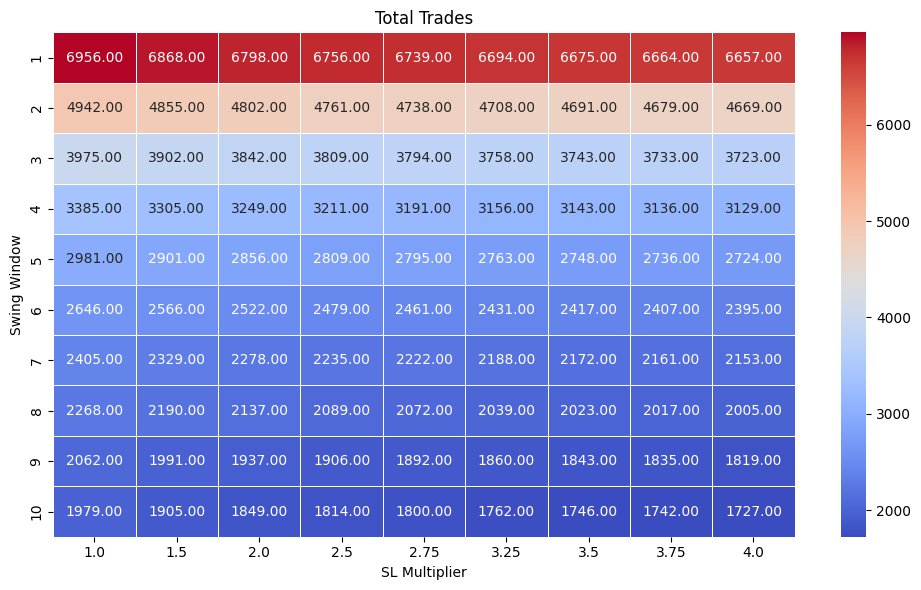

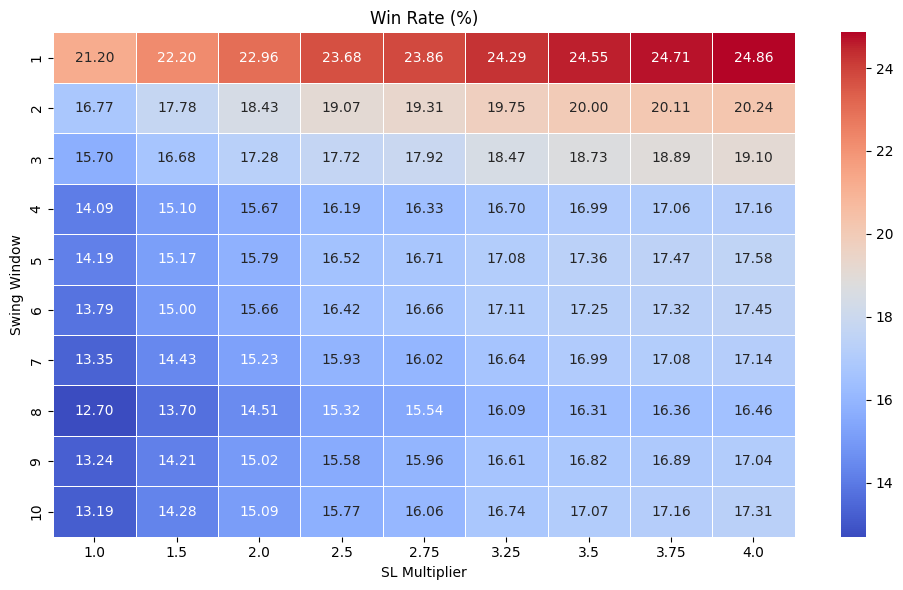

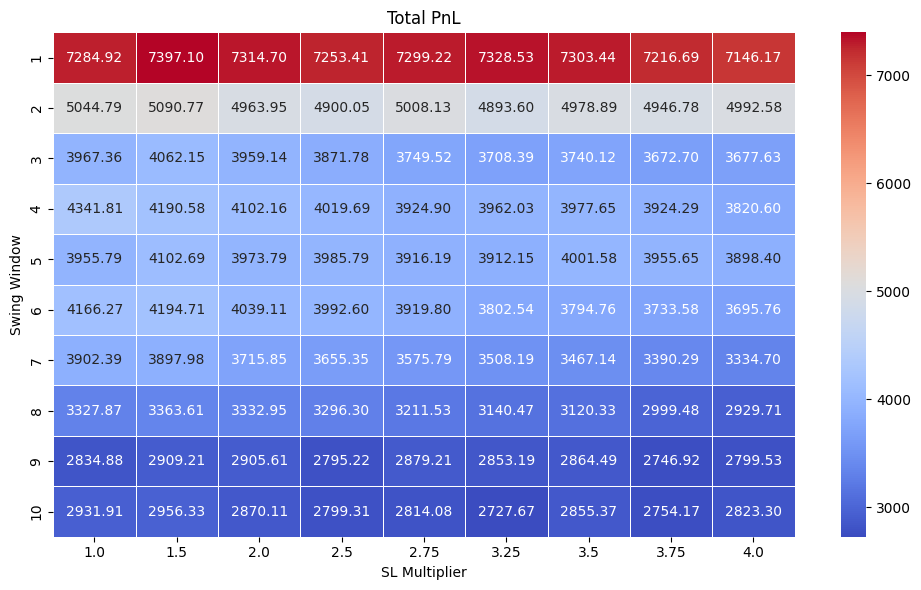

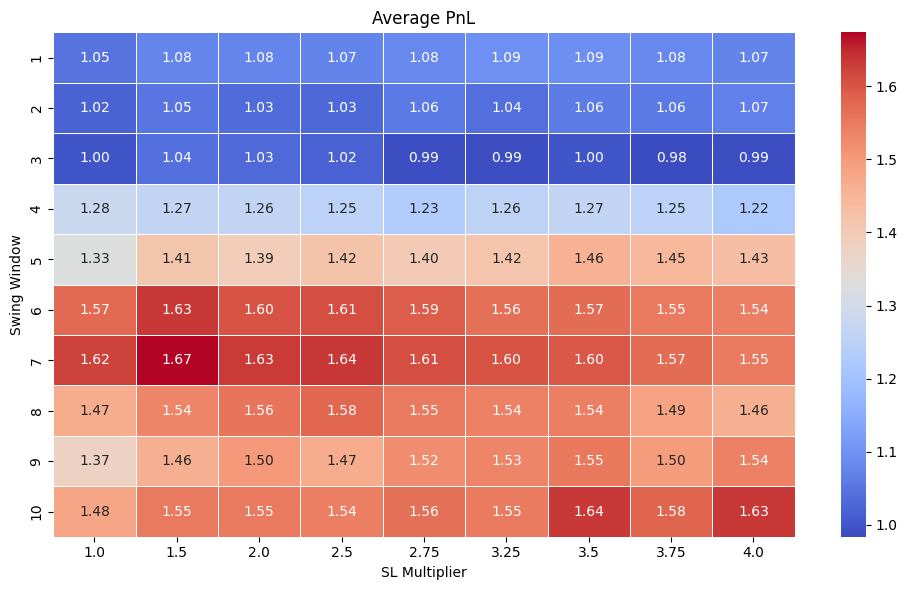

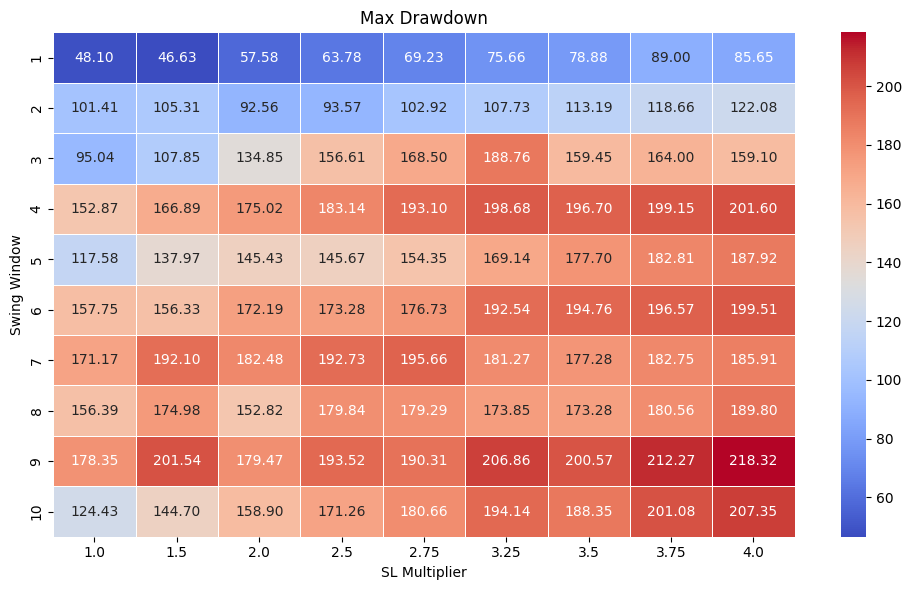

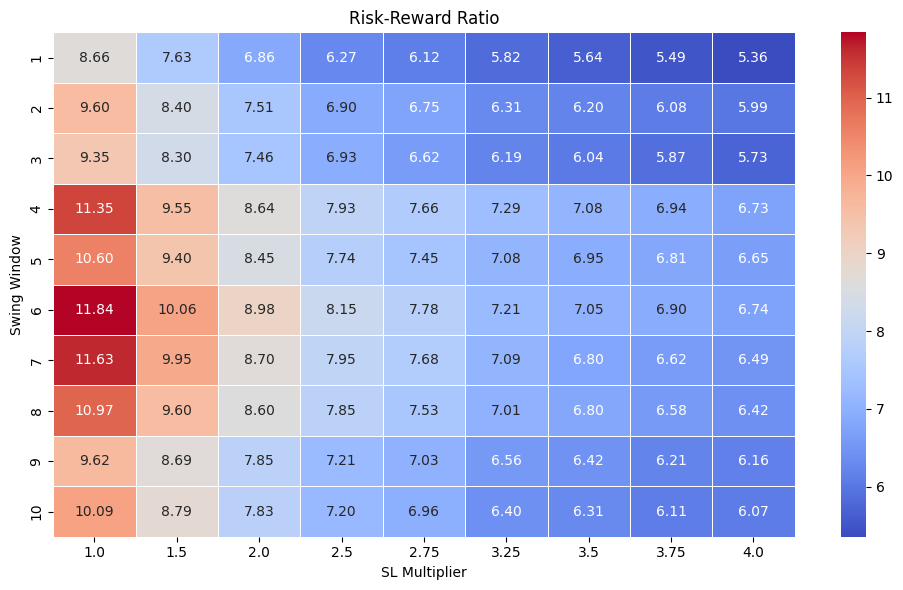

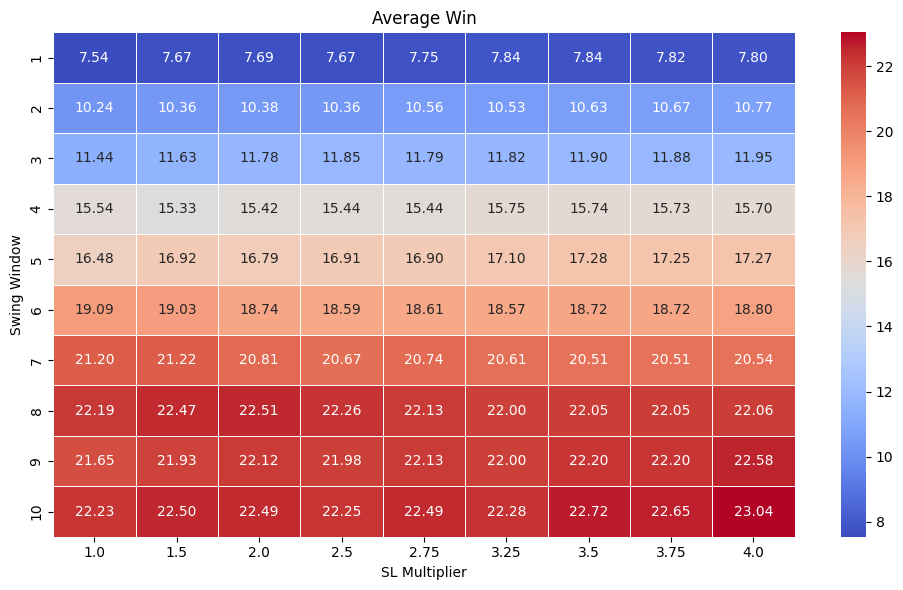

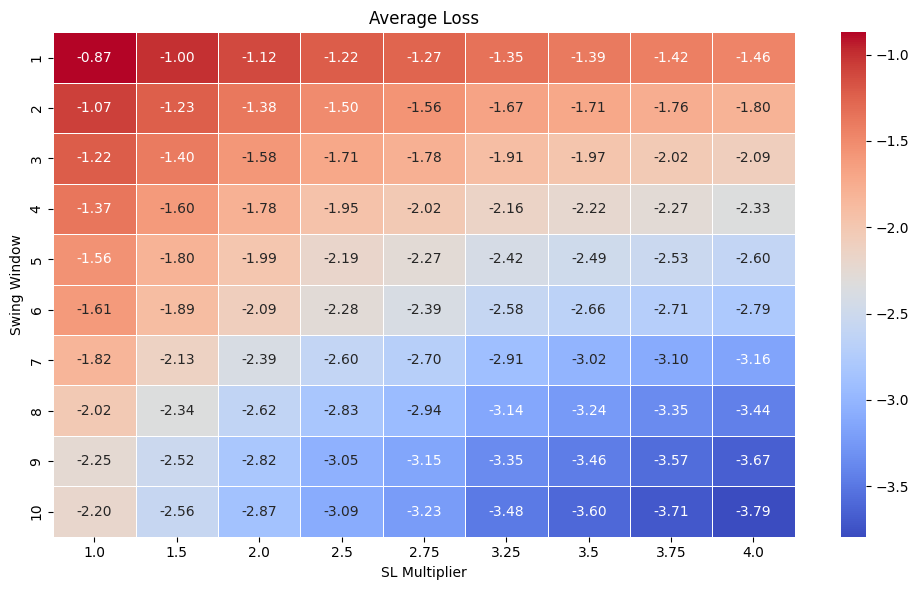

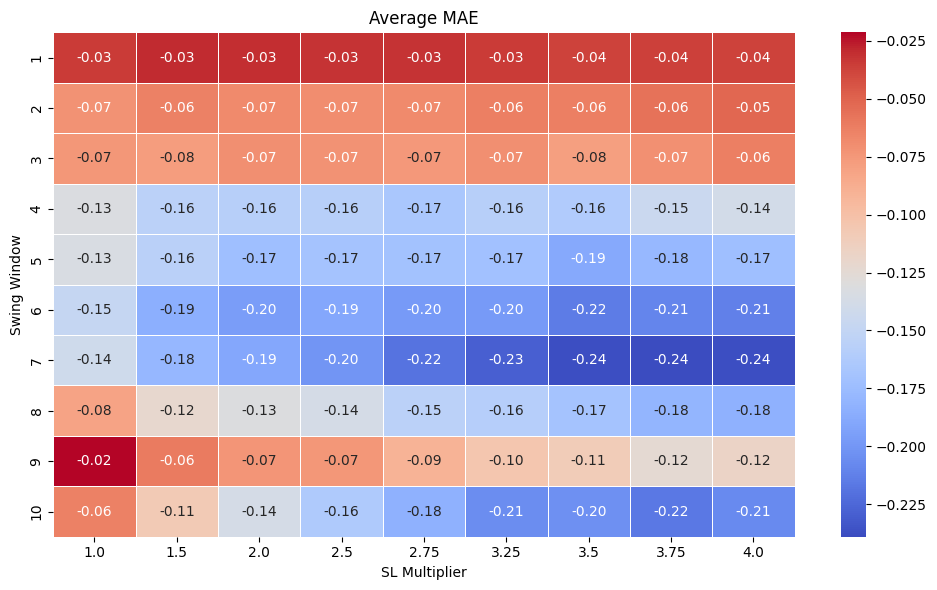

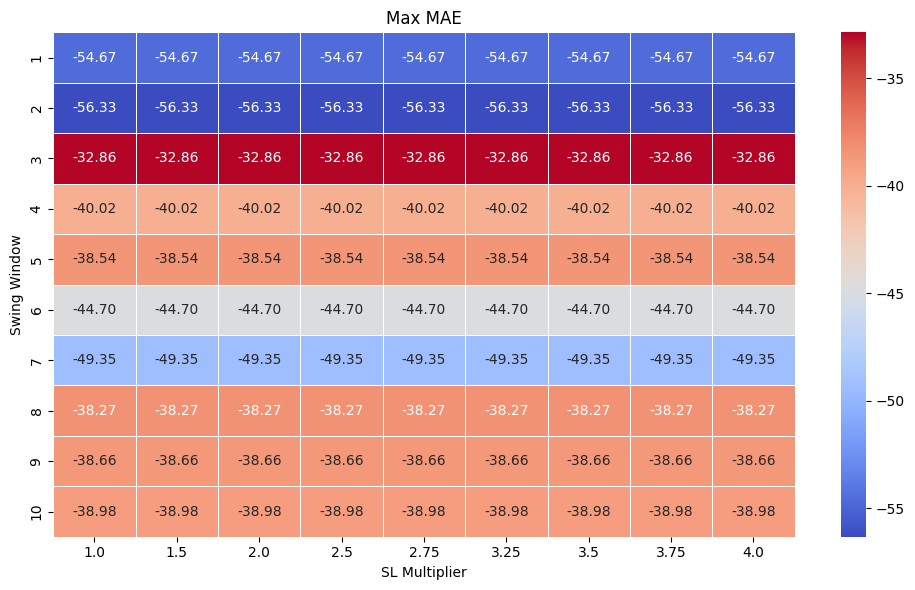

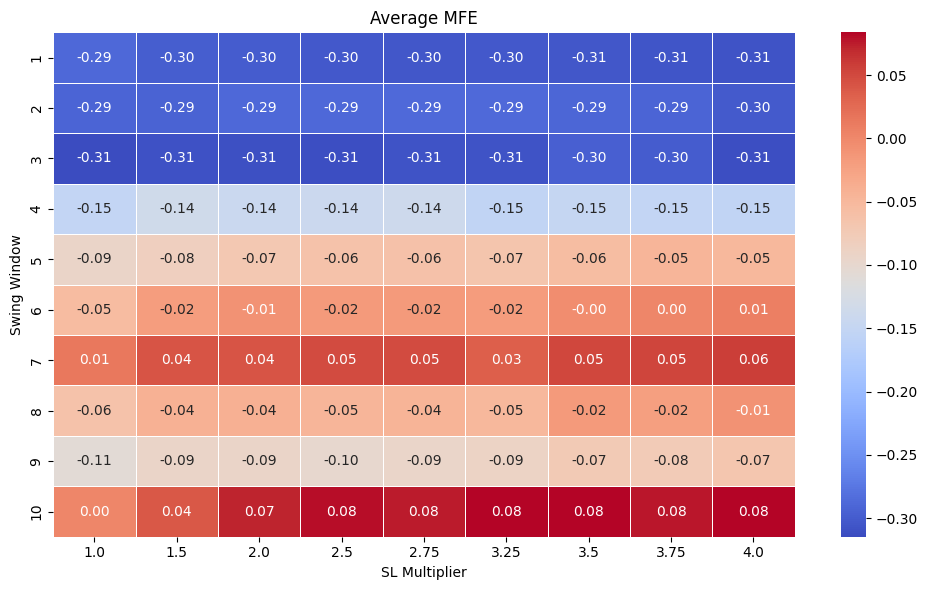

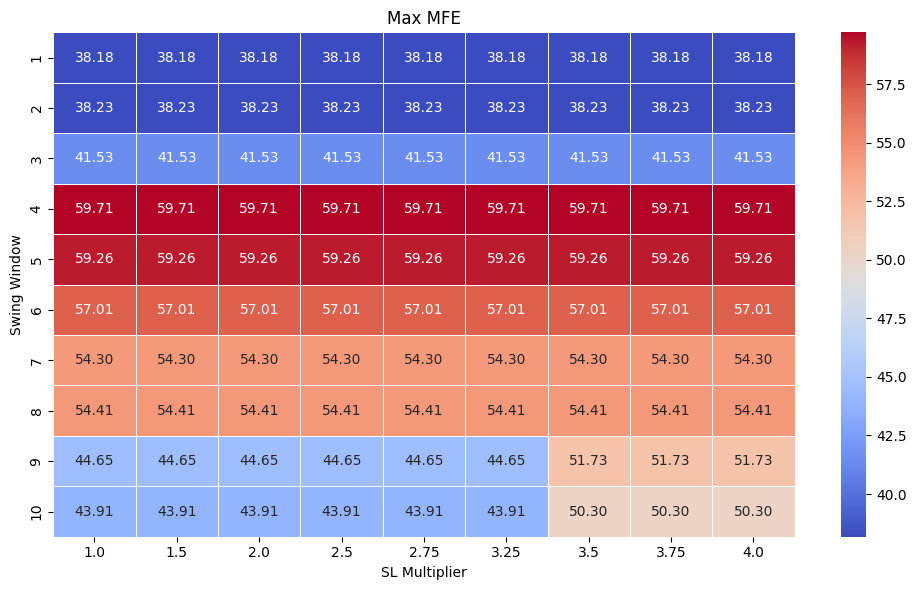

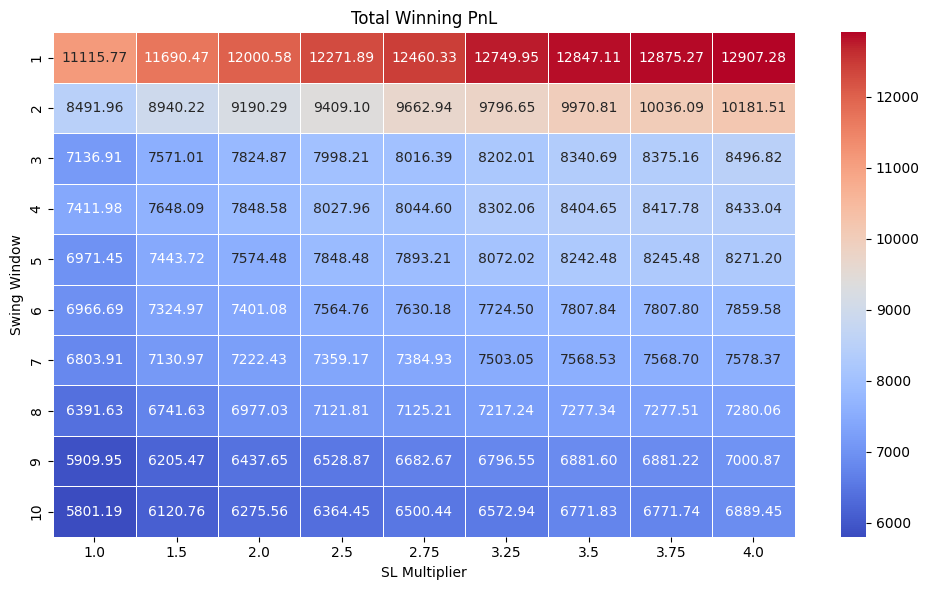

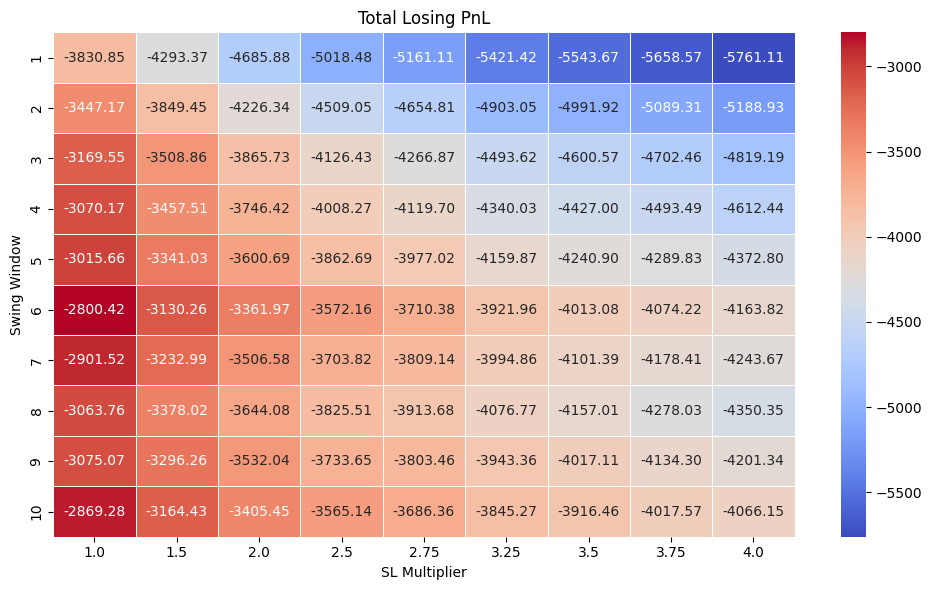

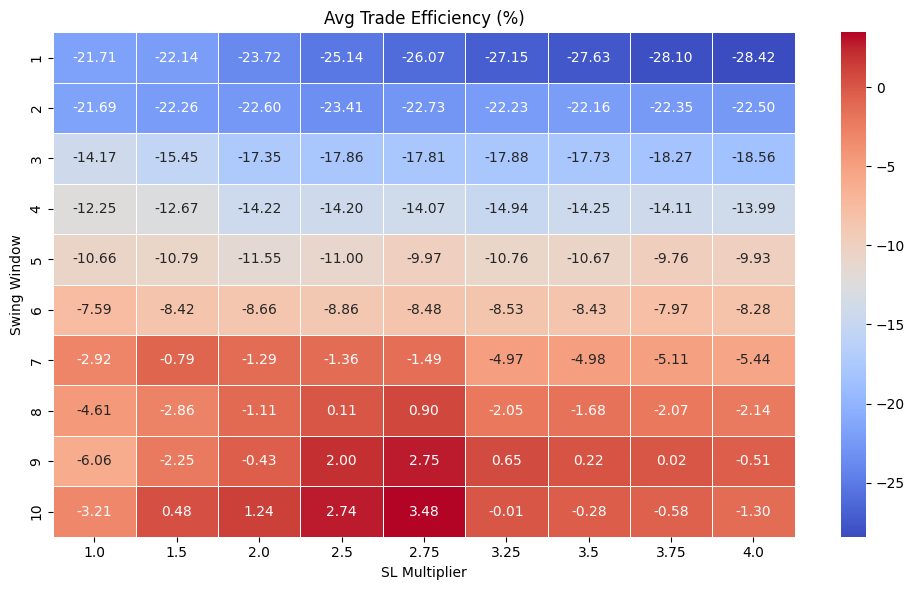

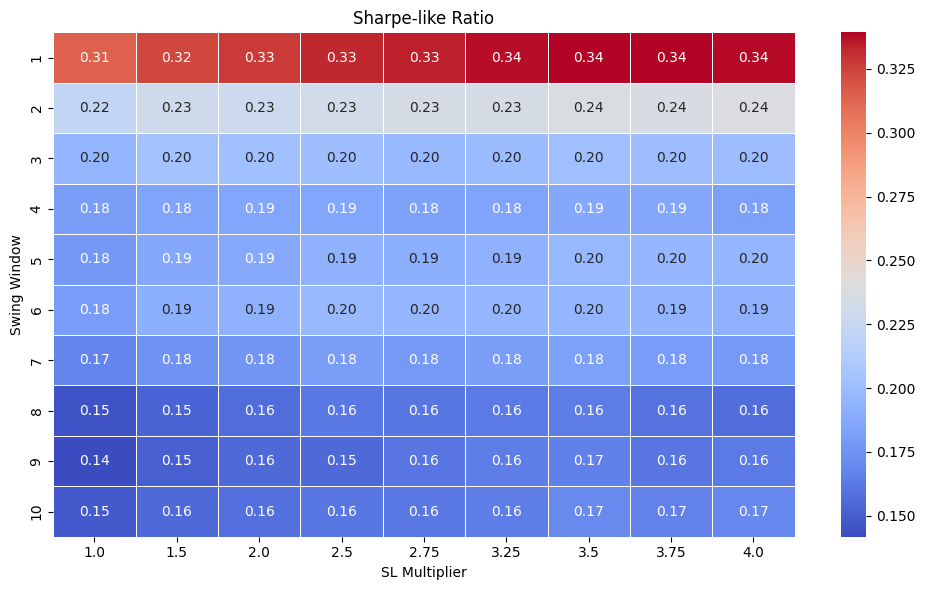

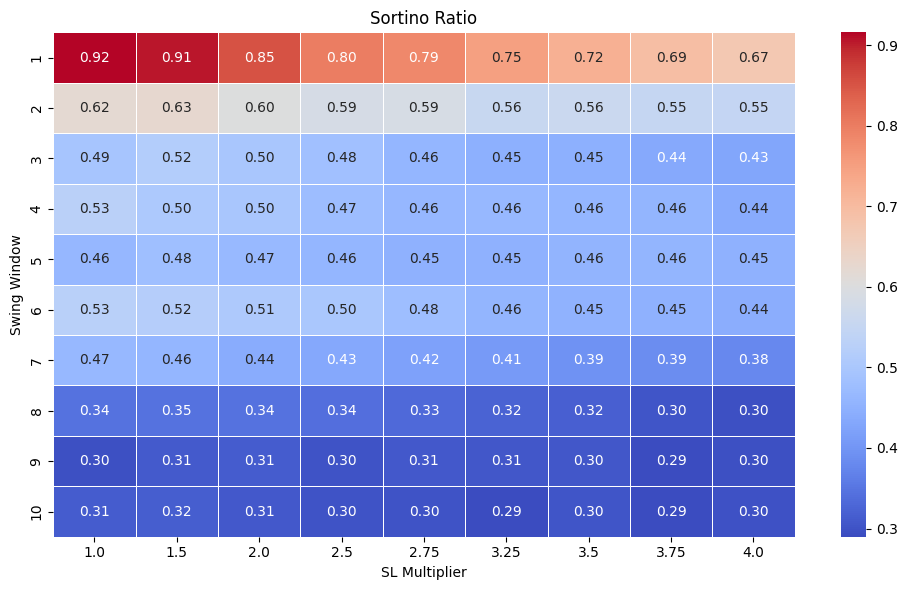

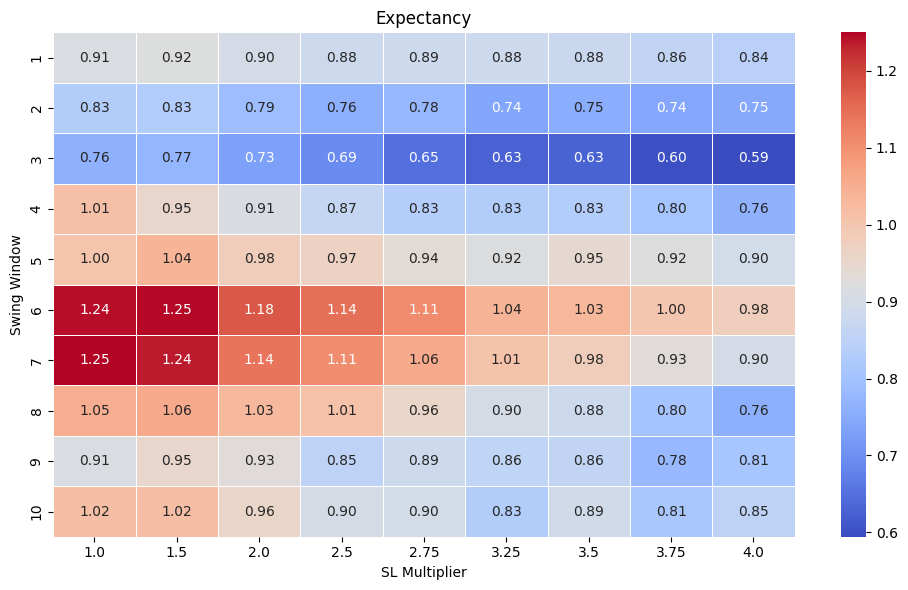

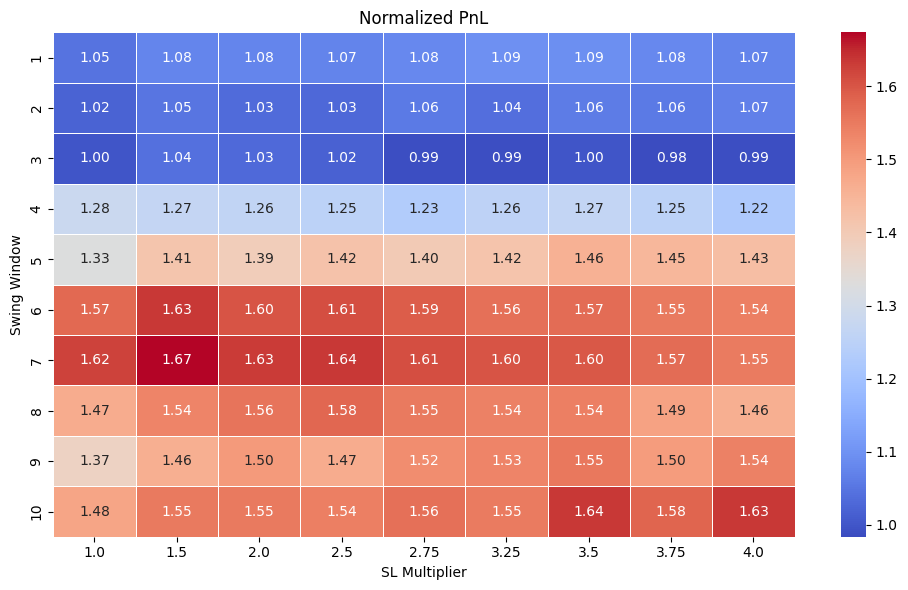

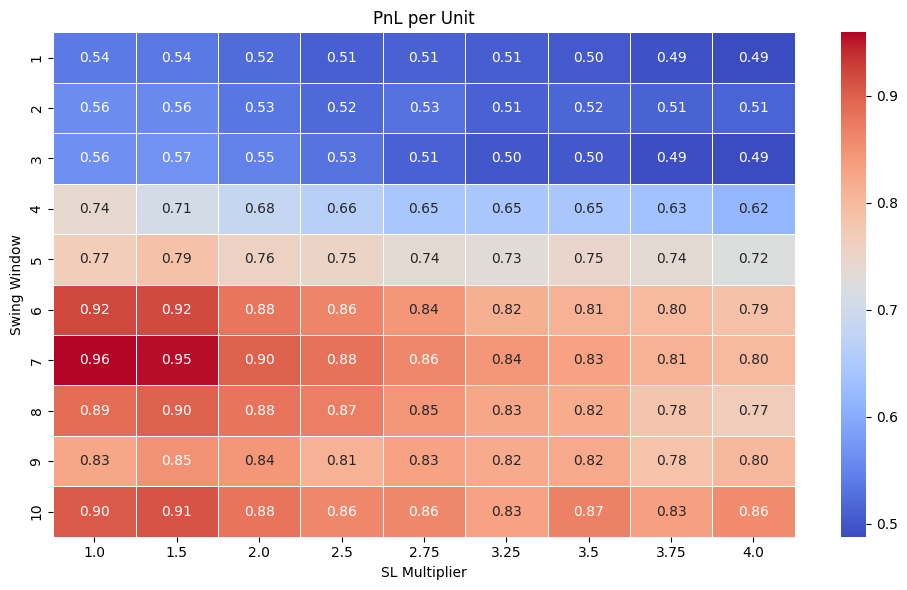

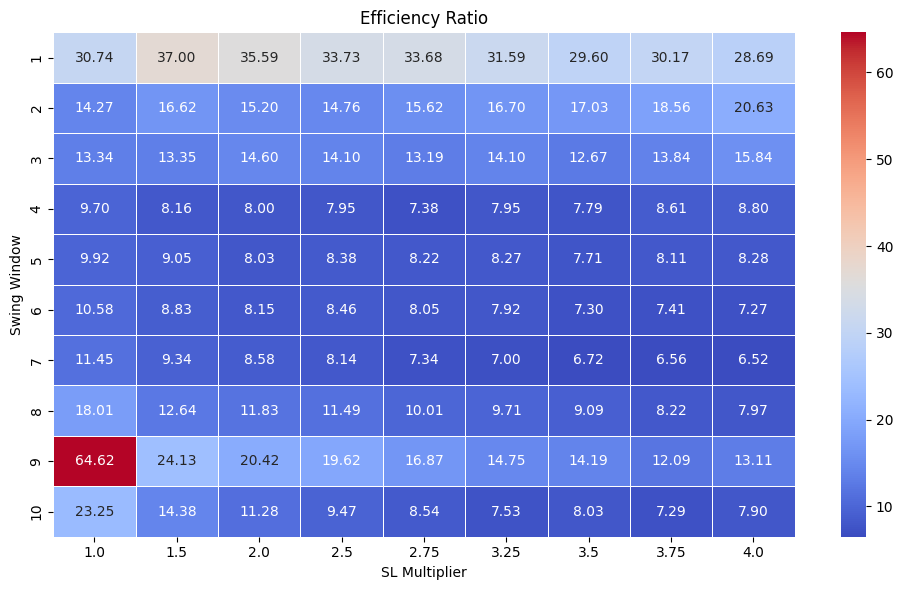

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
summary_path = r"Parameters Comparison Summary/summary_results.csv"
df = pd.read_csv(summary_path)

# Function to plot a heatmap for a given metric
def plot_heatmap(metric, title, cmap='coolwarm', fmt='.2f'):
    pivot = df.pivot(index="Window", columns="SL Multiplier", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5)
    plt.title(title)
    plt.xlabel("SL Multiplier")
    plt.ylabel("Swing Window")
    plt.tight_layout()
    plt.show()

# List of metrics and corresponding titles
metrics_to_plot = [
    ("Total Trades", "Total Trades"),
    ("Win Rate (%)", "Win Rate (%)"),
    ("Total PnL", "Total PnL"),
    ("Average PnL", "Average PnL"),
    ("Max Drawdown", "Max Drawdown"),
    ("Risk-Reward", "Risk-Reward Ratio"),
    ("Avg Win", "Average Win"),
    ("Avg Loss", "Average Loss"),
    ("Average MAE", "Average MAE"),
    ("Max MAE", "Max MAE"),
    ("Average MFE", "Average MFE"),
    ("Max MFE", "Max MFE"),
    ("Winning PnL", "Total Winning PnL"),
    ("Losing PnL", "Total Losing PnL"),
    ("Avg Trade Efficiency (%)", "Avg Trade Efficiency (%)"),
    ("Sharpe-like Ratio", "Sharpe-like Ratio"),
    ("Sortino Ratio", "Sortino Ratio"),
    ("Expectancy", "Expectancy"),
    ("Normalized PnL", "Normalized PnL"),
    ("PnL per Unit", "PnL per Unit"),
    ("Efficiency Ratio", "Efficiency Ratio"),
]

# Generate heatmaps
for metric, title in metrics_to_plot:
    plot_heatmap(metric, title)



In [25]:
import os
import glob
import numpy as np
import pandas as pd

def safe_divide(a, b):
    return a / b if b != 0 else np.nan

trades_folder = 'all_trades'
pattern = os.path.join(trades_folder, "All_Trades_Window_*_SL_*.csv")
summary_rows = []
POINT_VALUE = 100  # Gold is $100 per point

for file in glob.glob(pattern):
    filename = os.path.basename(file)
    parts = filename.replace(".csv", "").split("_")
    window = int(parts[3])
    sl_mult = float(parts[5])

    summary = pd.read_csv(file)
    if summary.empty or 'PnL' not in summary.columns:
        print(f"⚠️ Skipping file due to missing data: {filename}")
        continue

    # Scale dollar values
    summary['PnL'] *= POINT_VALUE
    summary['Cumulative PnL'] *= POINT_VALUE
    summary['MAE'] *= POINT_VALUE
    summary['MFE'] *= POINT_VALUE

    total_trades = len(summary)
    win_trades = (summary['PnL'] > 0).sum()
    win_rate = win_trades / total_trades * 100
    total_pnl = summary['PnL'].sum()
    avg_pnl = summary['PnL'].mean()
    max_drawdown = (summary['Cumulative PnL'].cummax() - summary['Cumulative PnL']).max()
    avg_win = summary.loc[summary['PnL'] > 0, 'PnL'].mean()
    avg_loss = summary.loc[summary['PnL'] < 0, 'PnL'].mean()
    rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
    avg_mae = summary['MAE'].mean()
    max_mae = summary['MAE'].min()
    avg_mfe = summary['MFE'].mean()
    max_mfe = summary['MFE'].max()
    winning_pnl = summary.loc[summary['PnL'] > 0, 'PnL'].sum()
    losing_pnl = summary.loc[summary['PnL'] < 0, 'PnL'].sum()
    efficiency = (summary['PnL'] / summary['MFE'].replace(0, np.nan)) * 100
    avg_efficiency = efficiency.mean()
    total_units = summary['Units'].sum()

    sharpe_like = safe_divide(avg_pnl, np.std([avg_win, abs(avg_loss)]))
    expectancy = (win_rate / 100) * avg_win + (1 - win_rate / 100) * avg_loss
    normalized_pnl = safe_divide(total_pnl, total_trades)
    pnl_per_unit = safe_divide(total_pnl, total_units)
    efficiency_ratio = safe_divide(avg_pnl, abs(avg_mae))

    downside_returns = summary[summary['PnL'] < 0]['PnL']
    downside_deviation = downside_returns.std() if not downside_returns.empty else 0
    sortino_ratio = safe_divide(avg_pnl, downside_deviation)

    summary_rows.append({
        'Window': window,
        'SL Multiplier': sl_mult,
        'Total Trades': total_trades,
        'Total Units': total_units,
        'Win Rate (%)': win_rate,
        'Total PnL': total_pnl,
        'Average PnL': avg_pnl,
        'Max Drawdown': max_drawdown,
        'Risk-Reward': rr,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
        'Average MAE': avg_mae,
        'Max MAE': max_mae,
        'Average MFE': avg_mfe,
        'Max MFE': max_mfe,
        'Winning PnL': winning_pnl,
        'Losing PnL': losing_pnl,
        'Avg Trade Efficiency (%)': avg_efficiency,
        'Sharpe-like Ratio': sharpe_like,
        'Sortino Ratio': sortino_ratio,
        'Expectancy': expectancy,
        'Normalized PnL': normalized_pnl,
        'PnL per Unit': pnl_per_unit,
        'Efficiency Ratio': efficiency_ratio
    })

# Save summary to CSV
summary_df = pd.DataFrame(summary_rows)
output_path = r"C:\Users\A\epat\Algo Project\Python-Projects\Parameters Comparison Summary\summary_results.csv"
summary_df.to_csv(output_path, index=False)
print("✅ Final summary saved to summary_results.csv with $100/point adjustment.")


✅ Final summary saved to summary_results.csv with $100/point adjustment.


In [29]:
import os
import glob
import numpy as np
import pandas as pd

# Safe division to avoid divide-by-zero issues
def safe_divide(a, b):
    return a / b if b != 0 else np.nan

# Folder containing all your trade result CSVs
trades_folder = 'all_trades_no_candle_confirmation'
pattern = os.path.join(trades_folder, "All_Trades_Window_*_SL_*.csv")

summary_rows = []

for file in glob.glob(pattern):
    filename = os.path.basename(file)
    parts = filename.replace(".csv", "").split("_")
    window = int(parts[3])
    sl_mult = float(parts[5])
    
    df = pd.read_csv(file)
    if df.empty:
        print(f'window = {window} and sl =  {sl_mult} file not found')
        continue

    total_trades = len(df)
    win_trades = (df['PnL'] > 0).sum()
    win_rate = win_trades / total_trades * 100
    total_pnl = df['PnL'].sum()
    avg_pnl = df['PnL'].mean()
    max_drawdown = (df['Cumulative PnL'].cummax() - df['Cumulative PnL']).max()
    avg_win = df.loc[df['PnL'] > 0, 'PnL'].mean()
    avg_loss = df.loc[df['PnL'] < 0, 'PnL'].mean()
    rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
    avg_mae = df['MAE'].mean()
    max_mae = df['MAE'].min()
    avg_mfe = df['MFE'].mean()
    max_mfe = df['MFE'].max()
    winning_pnl = df.loc[df['PnL'] > 0, 'PnL'].sum()
    losing_pnl = df.loc[df['PnL'] < 0, 'PnL'].sum()
    efficiency = (df['PnL'] / df['MFE'].replace(0, float('nan'))) * 100
    avg_efficiency = efficiency.mean()
    total_units = df['Units'].sum()

    # Derived Metrics
    sharpe_like = safe_divide(avg_pnl, np.std([avg_win, abs(avg_loss)]))
    expectancy = (win_rate / 100) * avg_win + (1 - win_rate / 100) * avg_loss
    normalized_pnl = safe_divide(total_pnl, total_trades)
    pnl_per_unit = safe_divide(total_pnl, total_units)
    efficiency_ratio = safe_divide(avg_pnl, abs(avg_mae))

    # True Downside Deviation (for Sortino)
    downside_returns = df[df['PnL'] < 0]['PnL']
    downside_deviation = downside_returns.std() if not downside_returns.empty else 0
    sortino_ratio = safe_divide(avg_pnl, downside_deviation)

    summary_rows.append({
        'Window': window,
        'SL Multiplier': sl_mult,
        'Total Trades': total_trades,
        'Total Units': total_units,
        'Win Rate (%)': win_rate,
        'Total PnL': total_pnl,
        'Average PnL': avg_pnl,
        'Max Drawdown': max_drawdown,
        'Risk-Reward': rr,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
        'Average MAE': avg_mae,
        'Max MAE': max_mae,
        'Average MFE': avg_mfe,
        'Max MFE': max_mfe,
        'Winning PnL': winning_pnl,
        'Losing PnL': losing_pnl,
        'Avg Trade Efficiency (%)': avg_efficiency,
        'Sharpe-like Ratio': sharpe_like,
        'Sortino Ratio': sortino_ratio,
        'Expectancy': expectancy,
        'Normalized PnL': normalized_pnl,
        'PnL per Unit': pnl_per_unit,
        'Efficiency Ratio': efficiency_ratio
    })

# Save to summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_output_path = r"C:\Users\A\epat\Algo Project\Python-Projects\Parameters Comparison Summary\summary_results_no_candle_confimation.csv"
summary_df.to_csv(summary_output_path, index=False)
print("✅ Final summary saved to summary_results.csv with all key metrics.")


✅ Final summary saved to summary_results.csv with all key metrics.


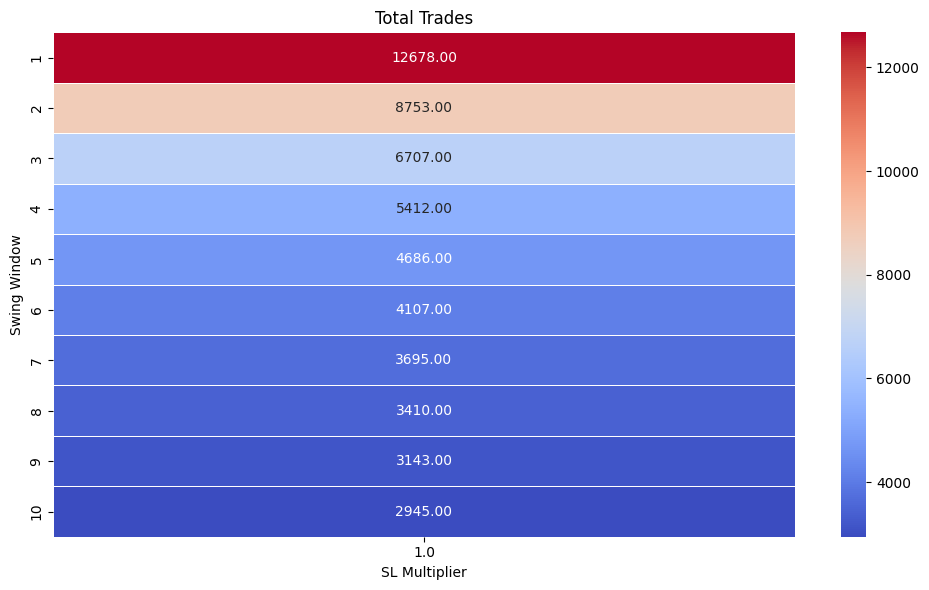

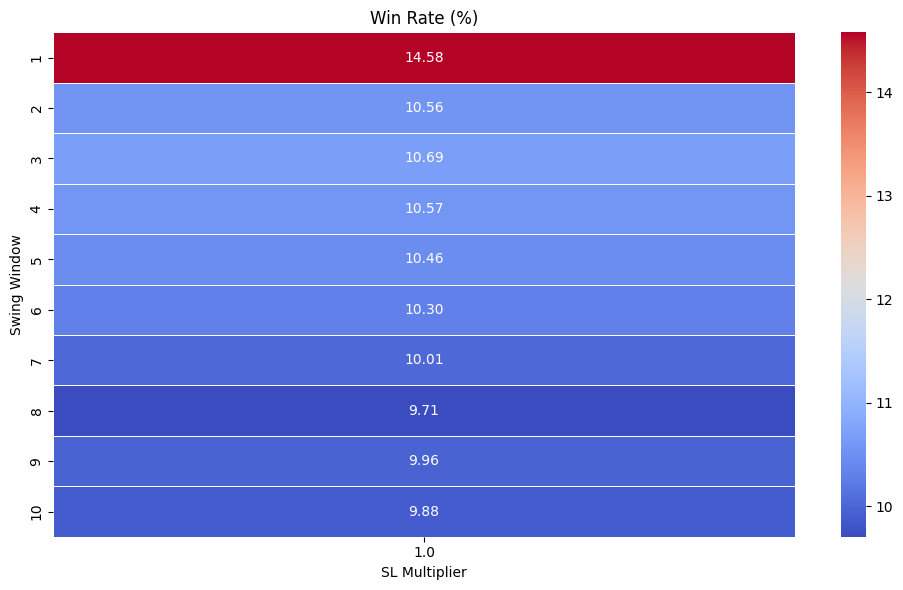

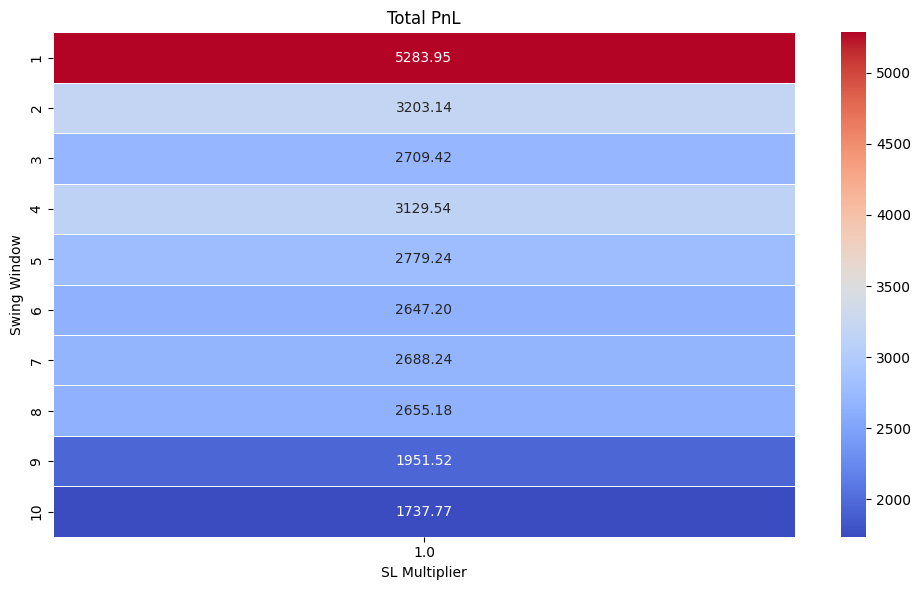

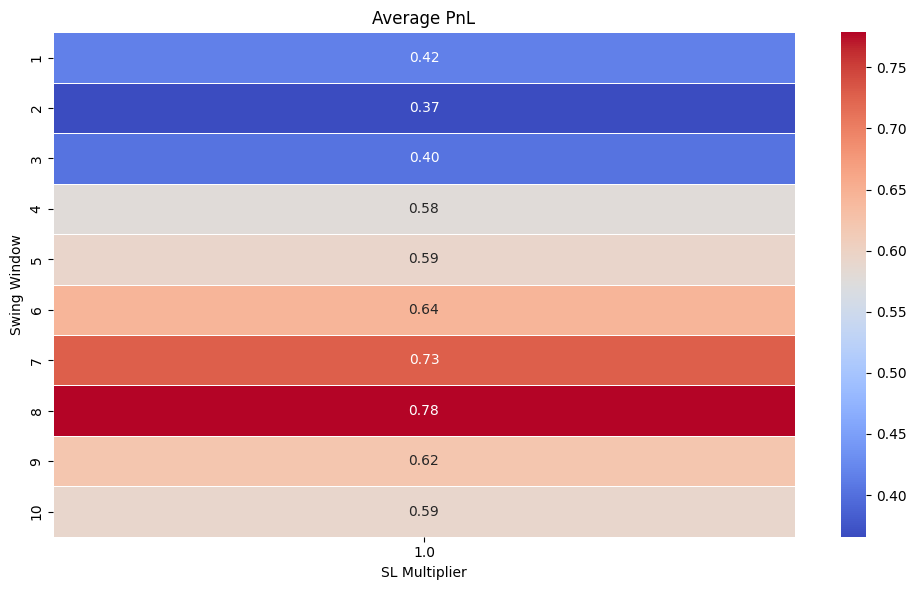

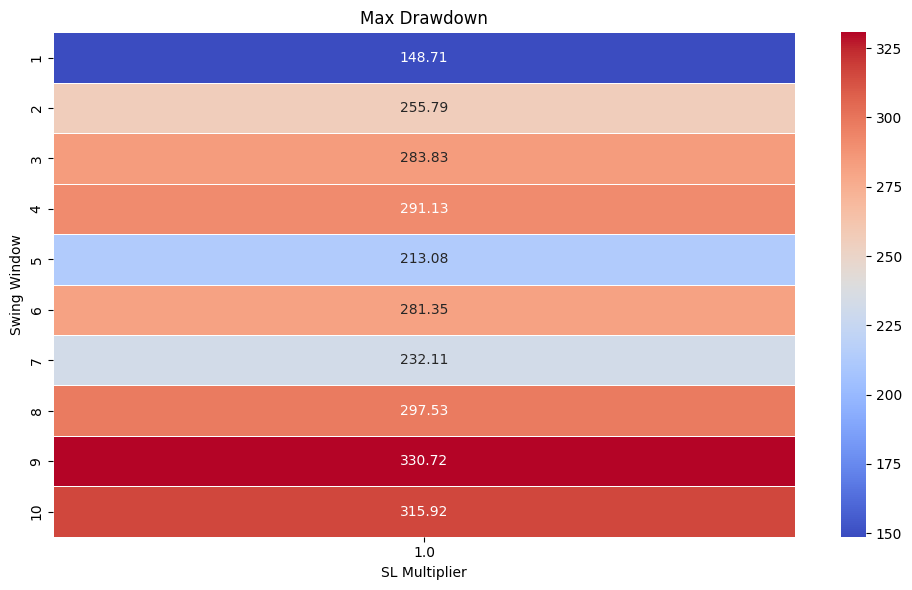

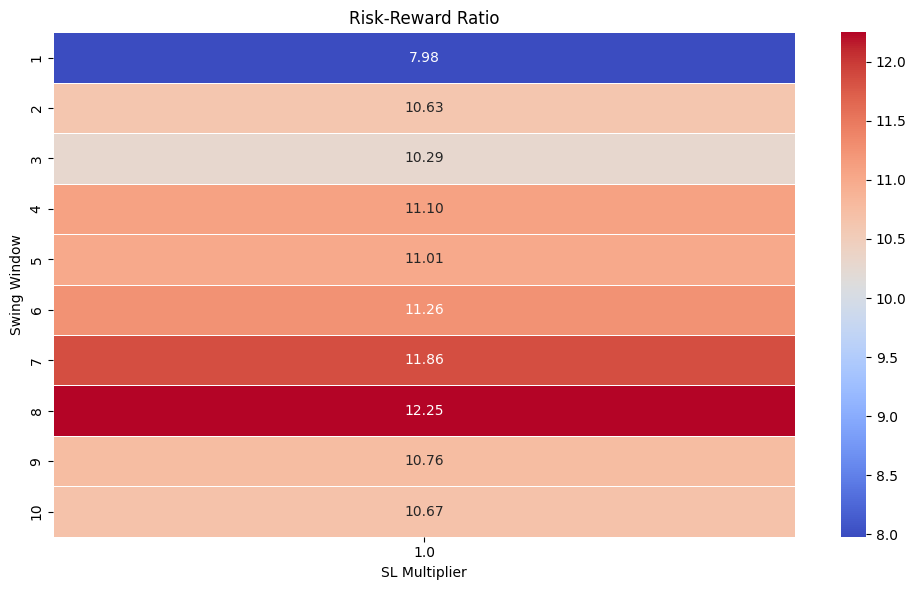

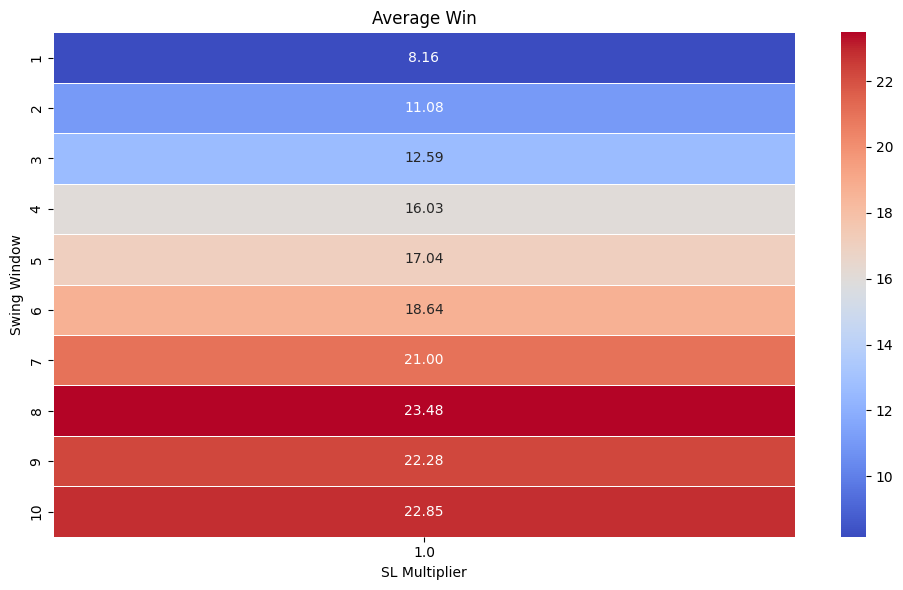

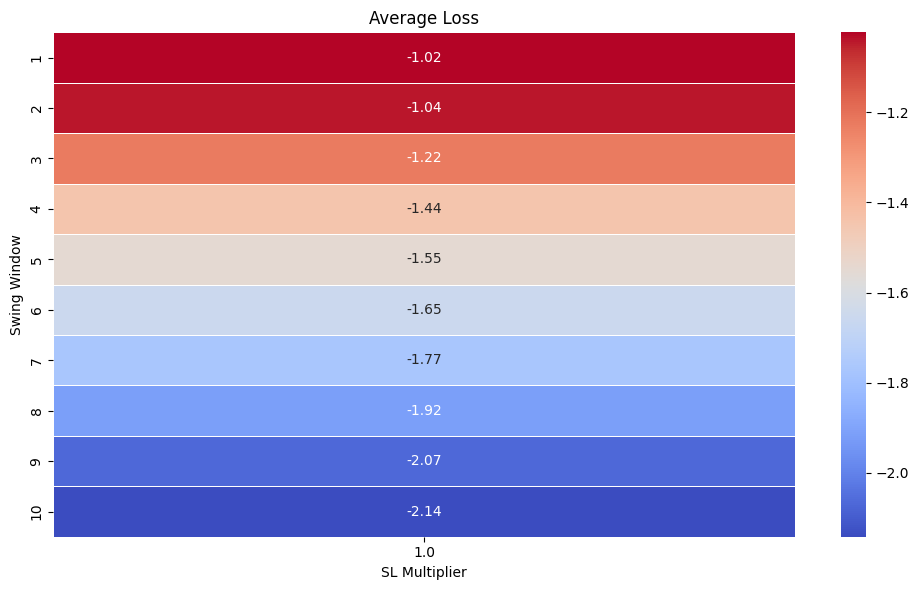

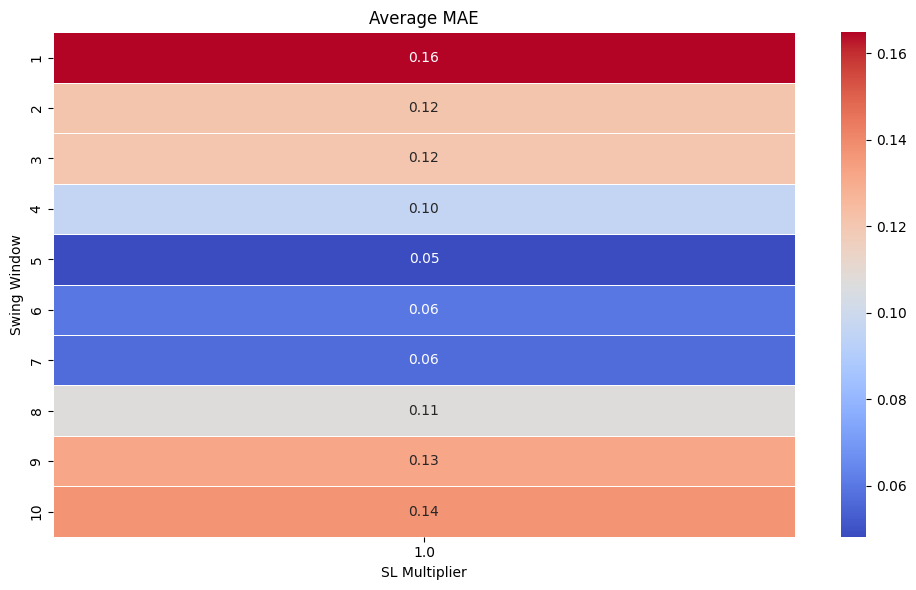

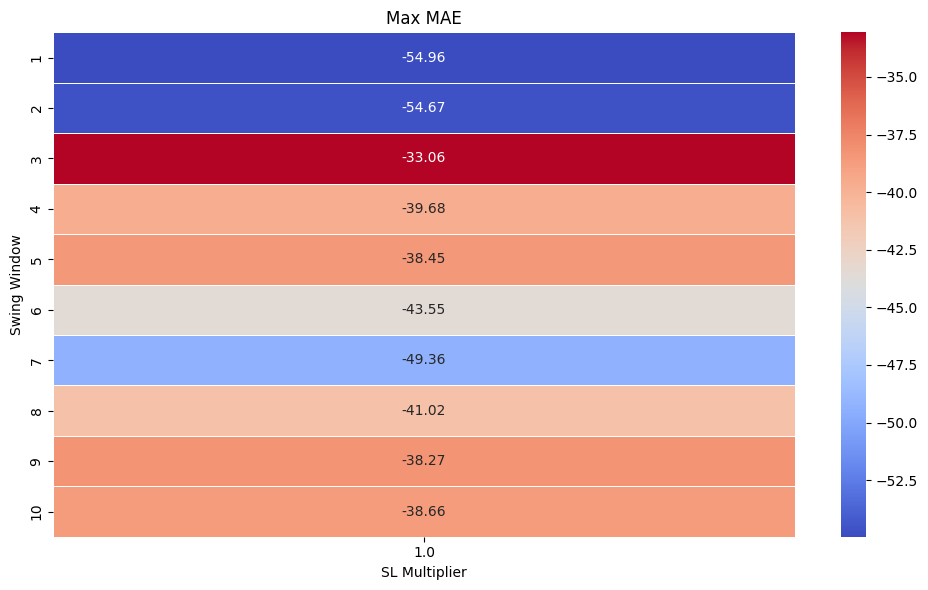

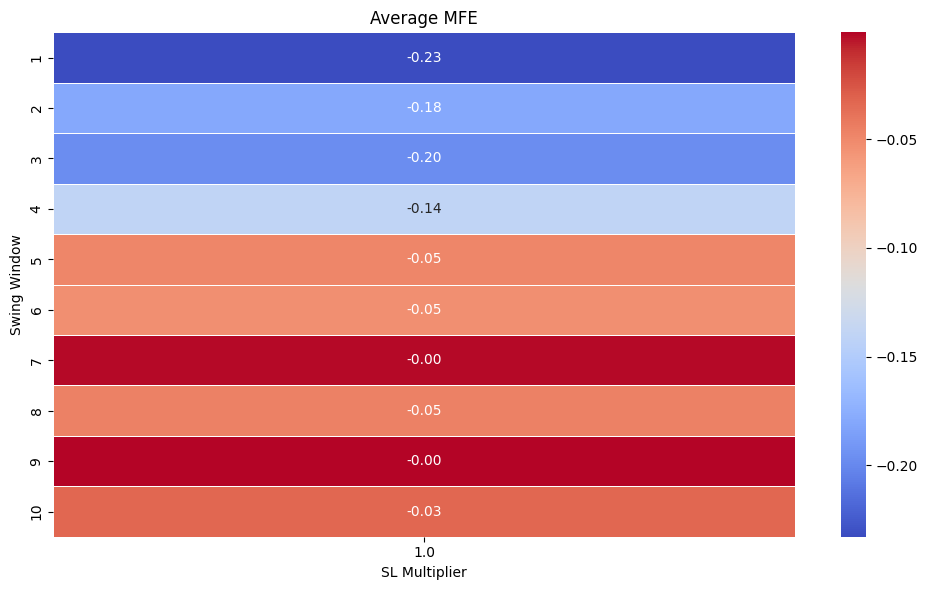

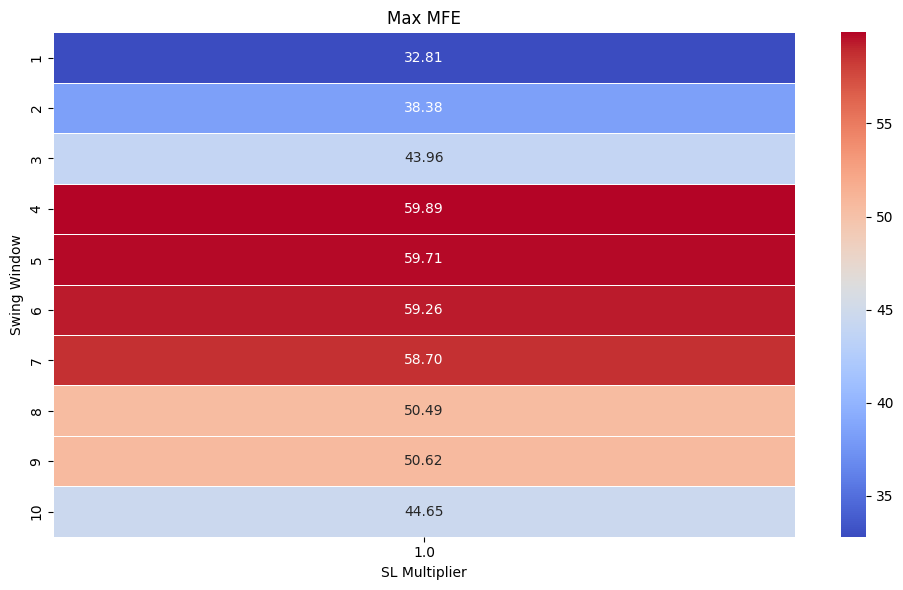

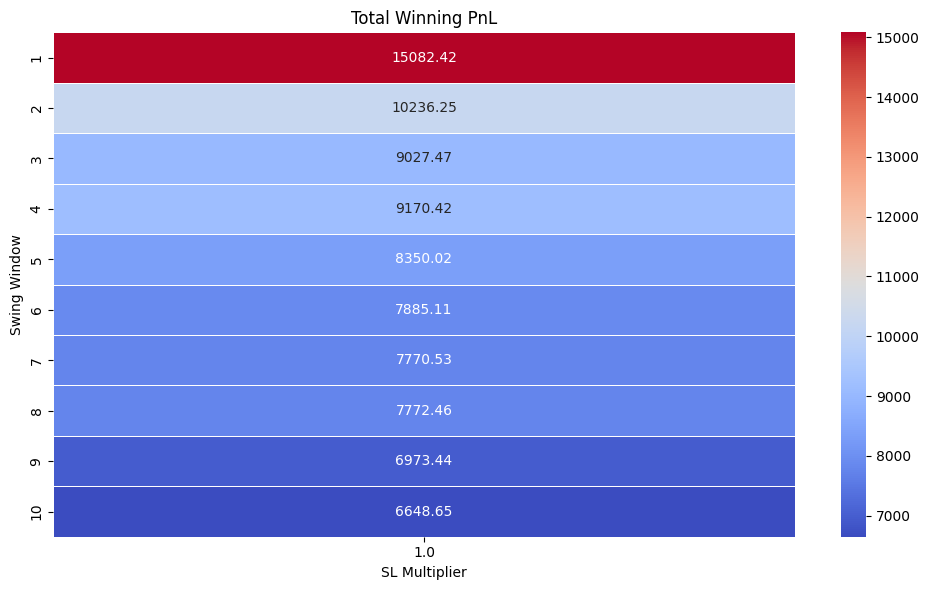

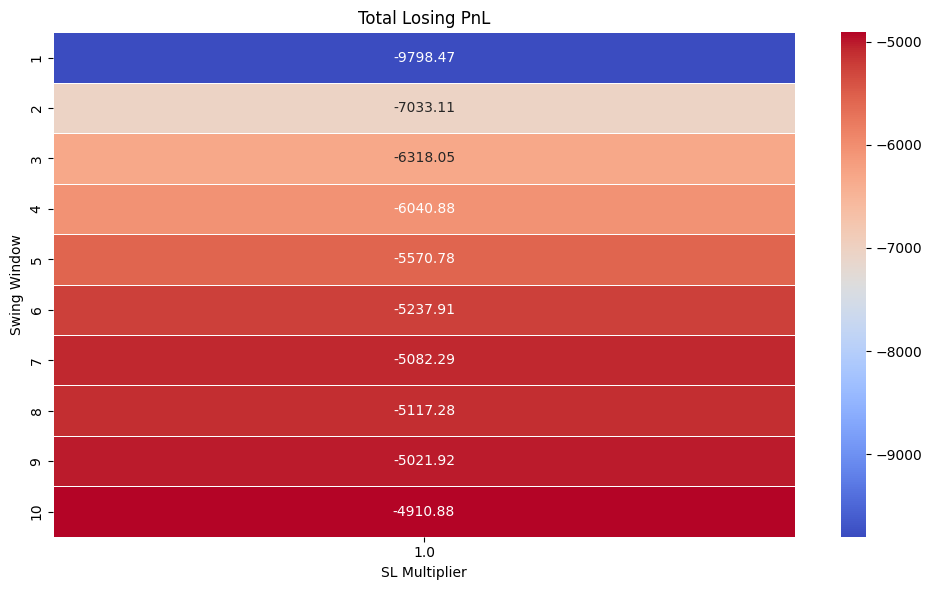

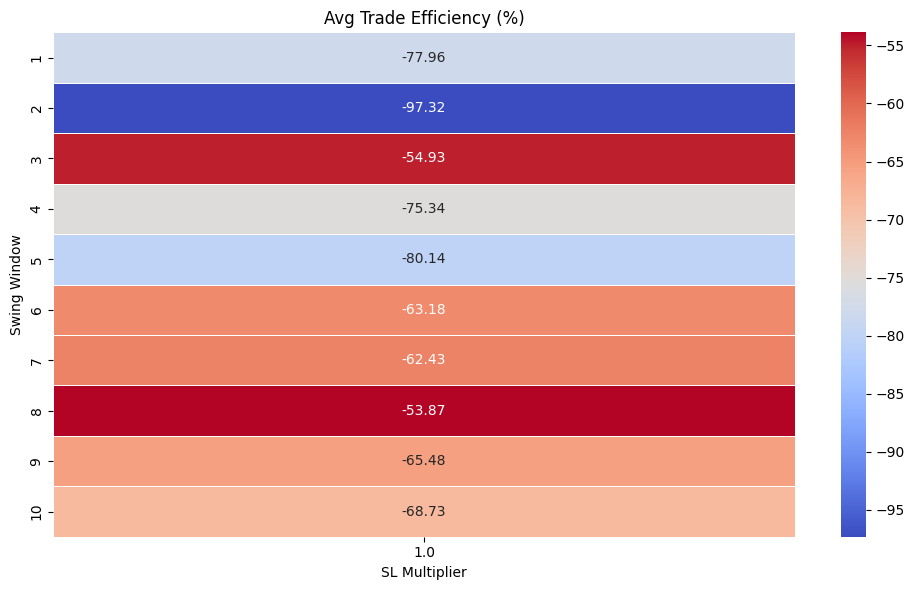

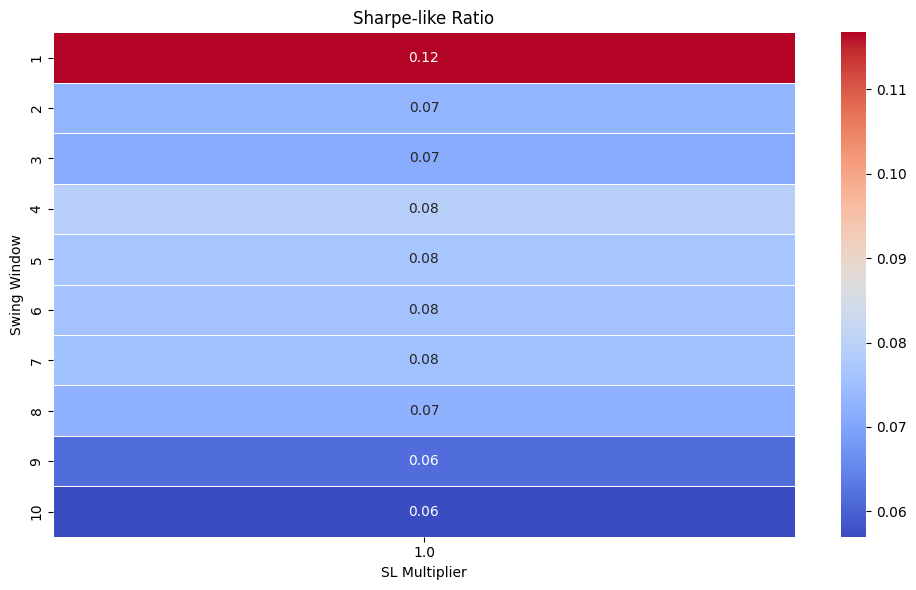

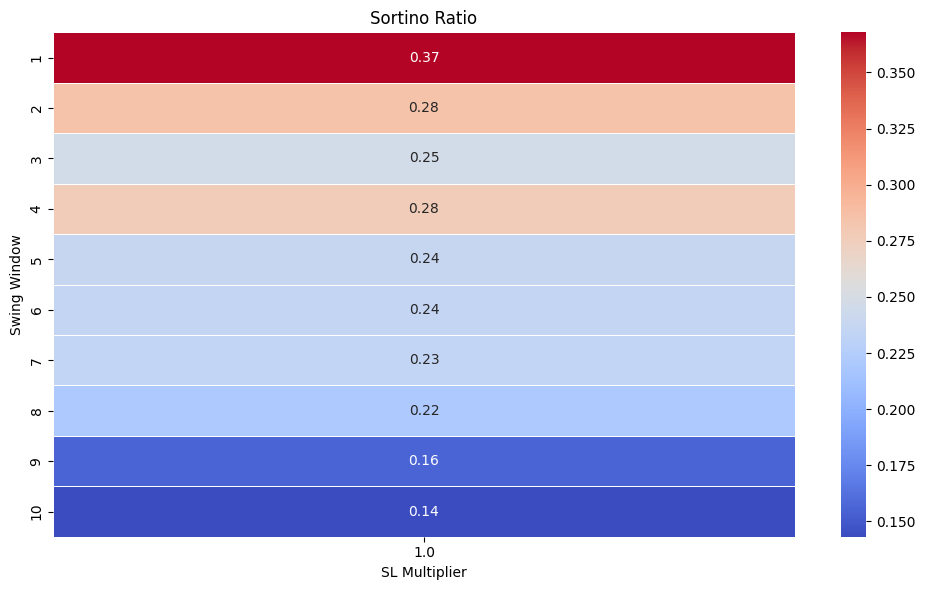

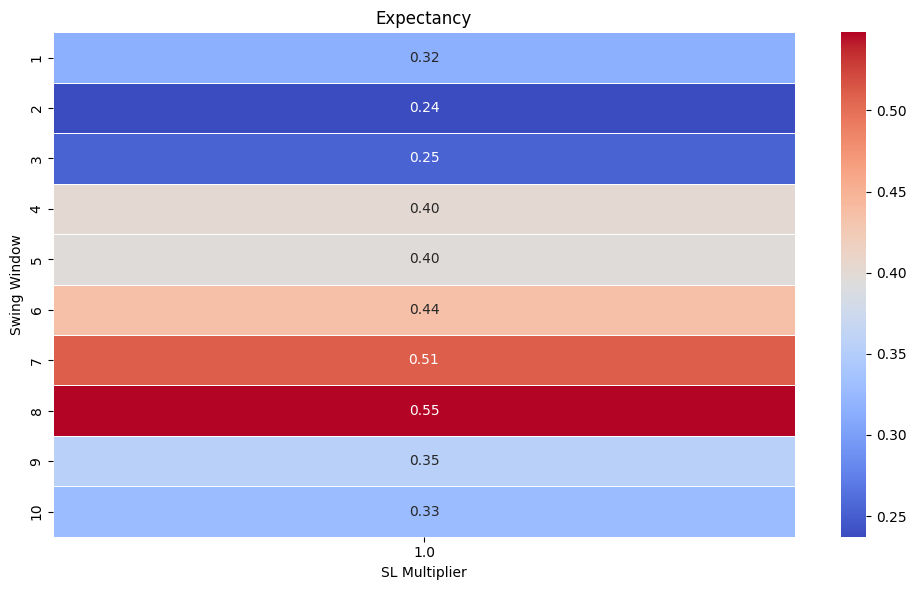

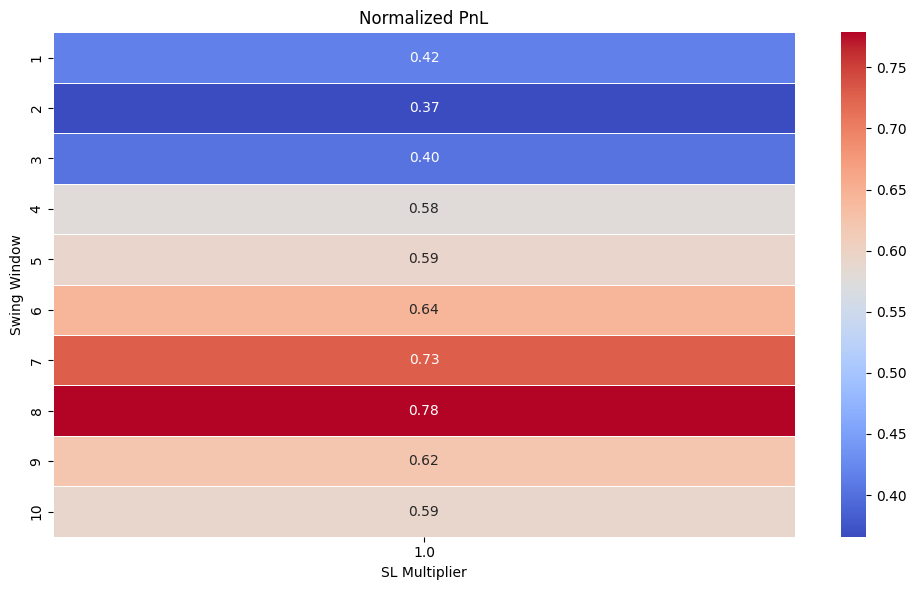

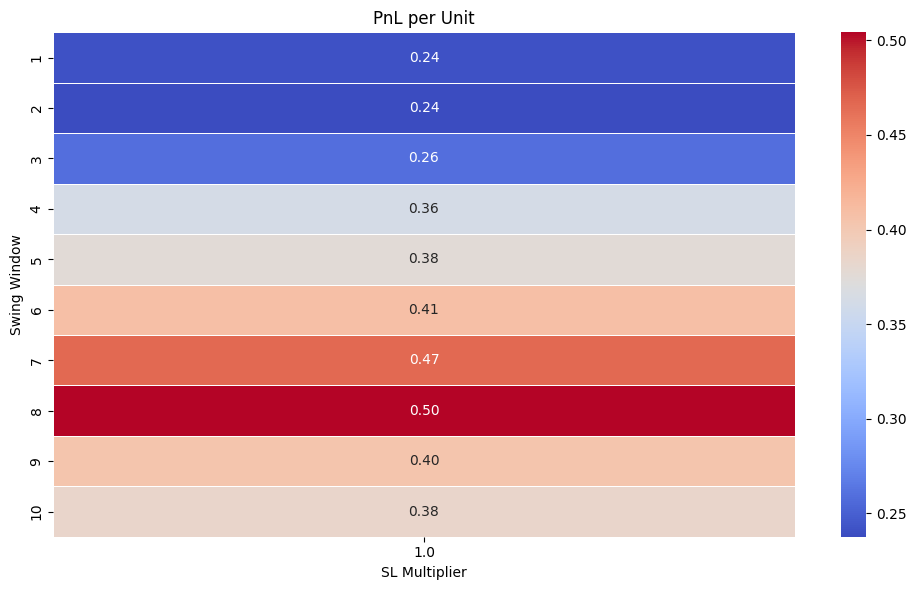

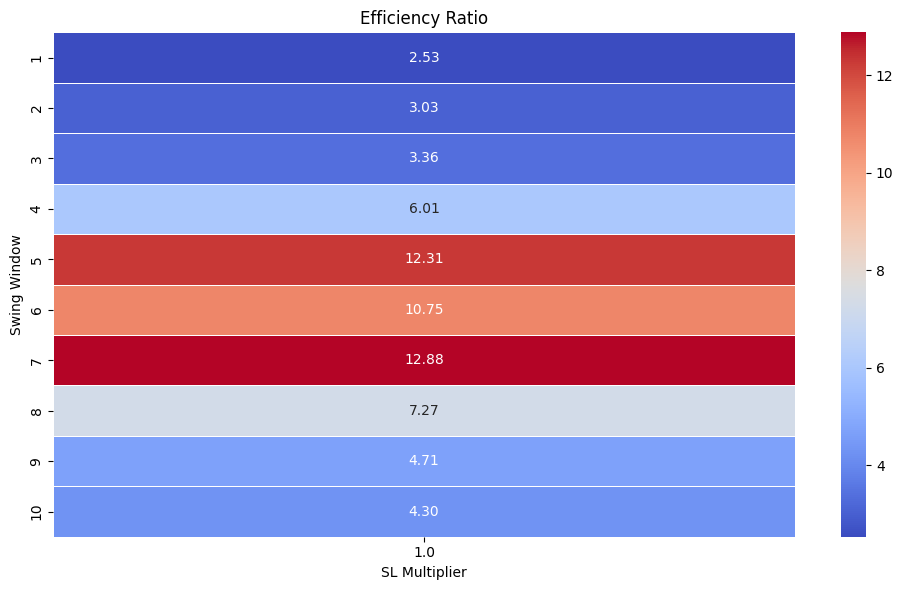

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
summary_path = r"Parameters Comparison Summary/summary_results_no_candle_confirmation.csv"
df = pd.read_csv(summary_path)

# Function to plot a heatmap for a given metric
def plot_heatmap(metric, title, cmap='coolwarm', fmt='.2f'):
    pivot = df.pivot(index="Window", columns="SL Multiplier", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5)
    plt.title(title)
    plt.xlabel("SL Multiplier")
    plt.ylabel("Swing Window")
    plt.tight_layout()
    plt.show()

# List of metrics and corresponding titles
metrics_to_plot = [
    ("Total Trades", "Total Trades"),
    ("Win Rate (%)", "Win Rate (%)"),
    ("Total PnL", "Total PnL"),
    ("Average PnL", "Average PnL"),
    ("Max Drawdown", "Max Drawdown"),
    ("Risk-Reward", "Risk-Reward Ratio"),
    ("Avg Win", "Average Win"),
    ("Avg Loss", "Average Loss"),
    ("Average MAE", "Average MAE"),
    ("Max MAE", "Max MAE"),
    ("Average MFE", "Average MFE"),
    ("Max MFE", "Max MFE"),
    ("Winning PnL", "Total Winning PnL"),
    ("Losing PnL", "Total Losing PnL"),
    ("Avg Trade Efficiency (%)", "Avg Trade Efficiency (%)"),
    ("Sharpe-like Ratio", "Sharpe-like Ratio"),
    ("Sortino Ratio", "Sortino Ratio"),
    ("Expectancy", "Expectancy"),
    ("Normalized PnL", "Normalized PnL"),
    ("PnL per Unit", "PnL per Unit"),
    ("Efficiency Ratio", "Efficiency Ratio"),
]

# Generate heatmaps
for metric, title in metrics_to_plot:
    plot_heatmap(metric, title)



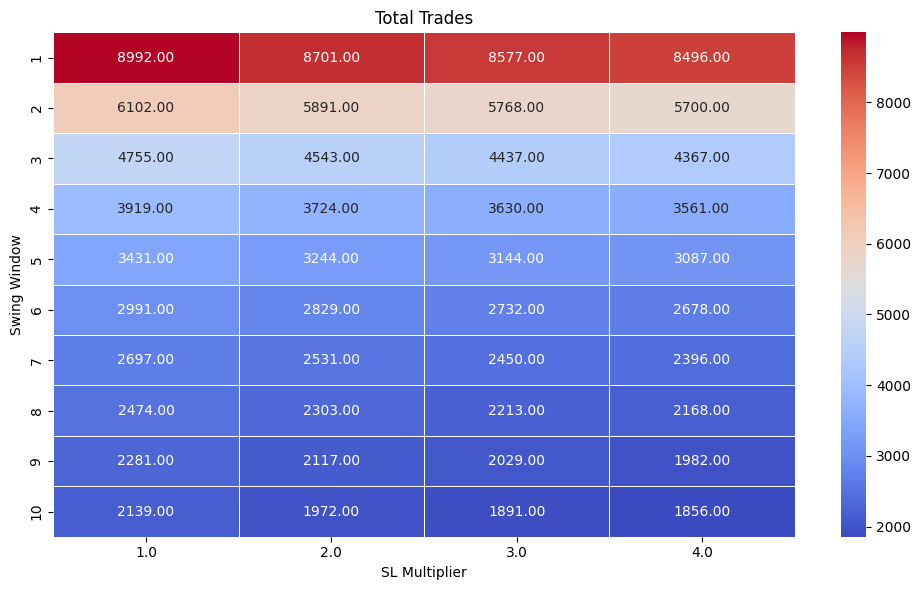

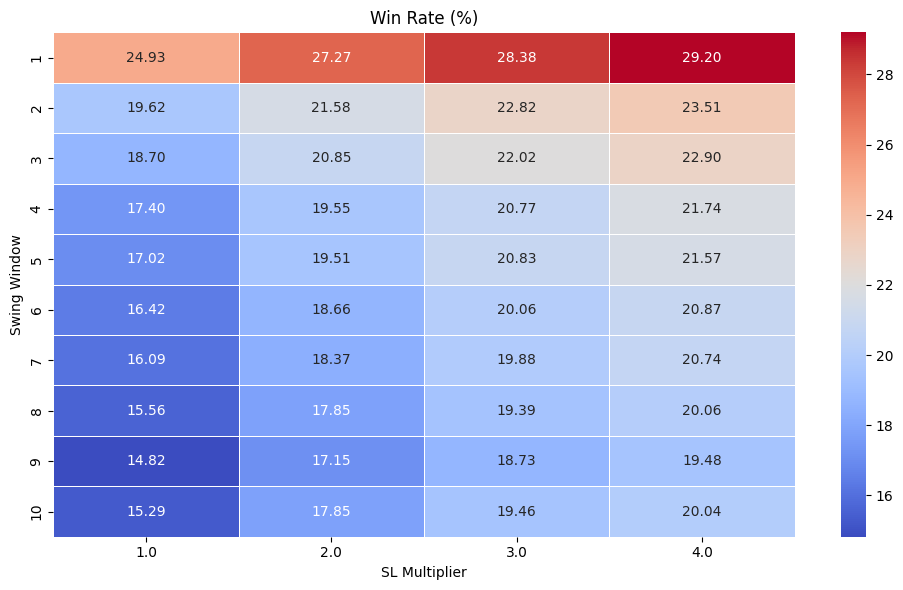

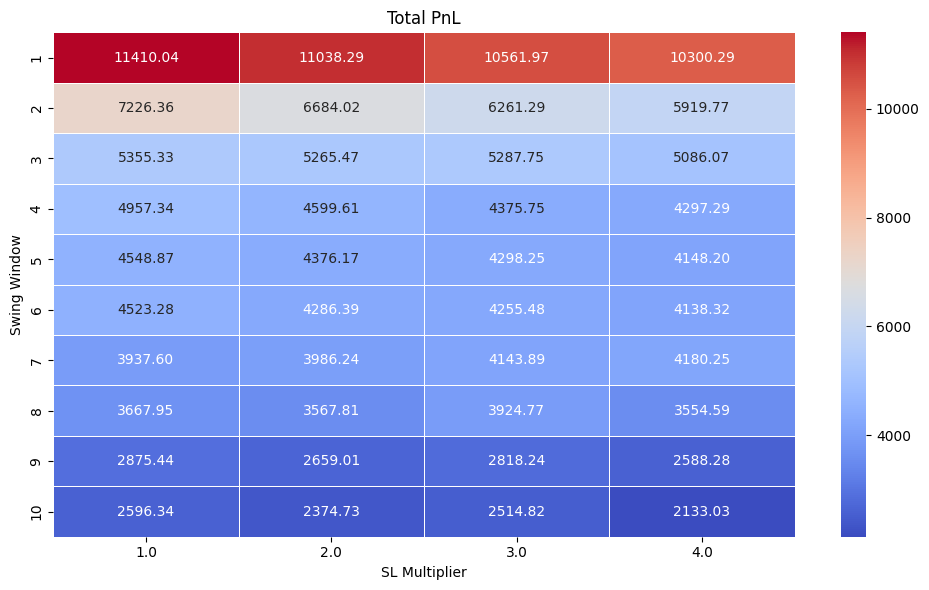

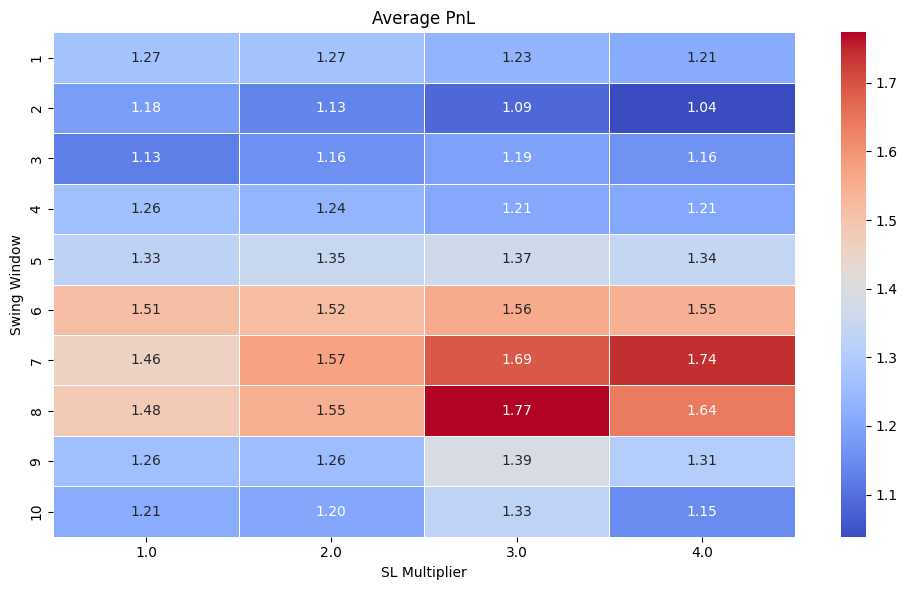

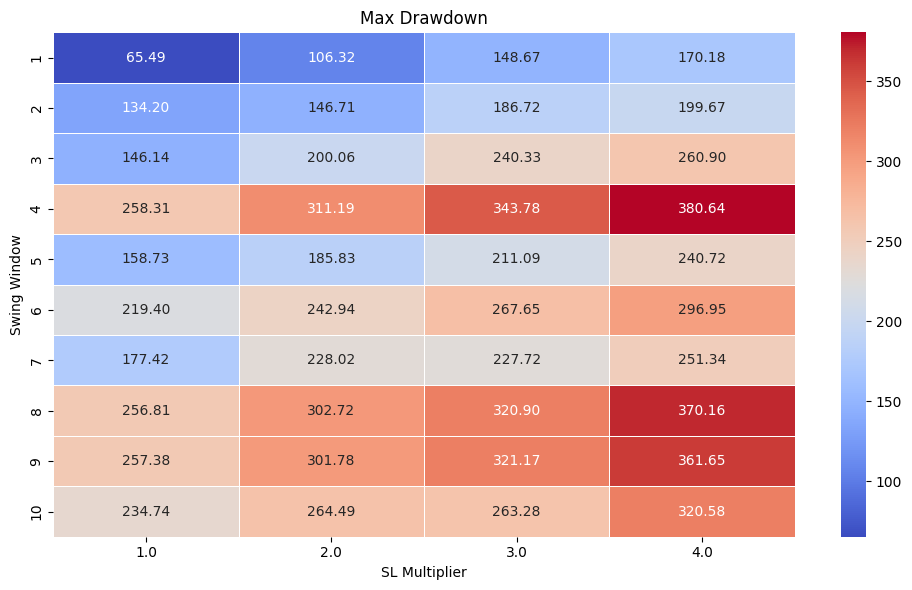

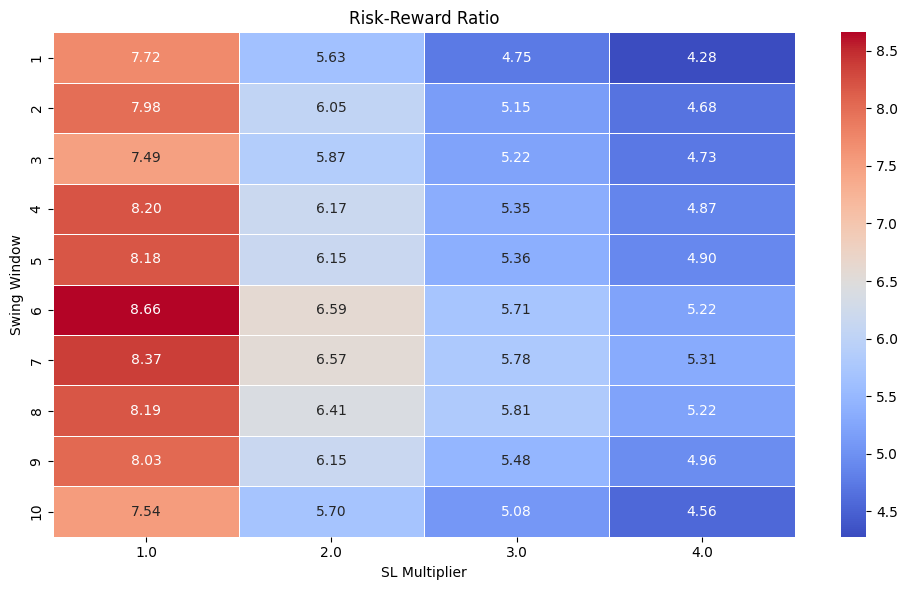

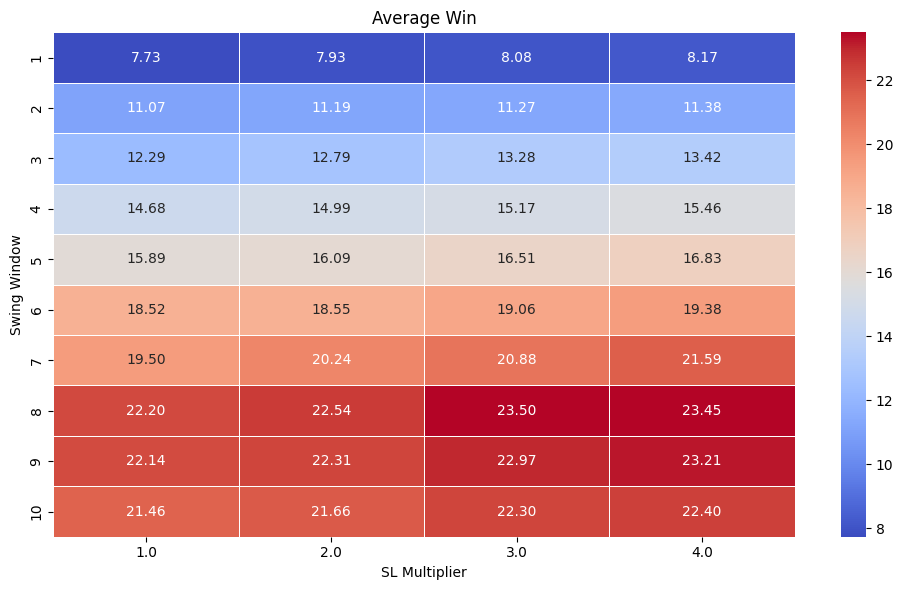

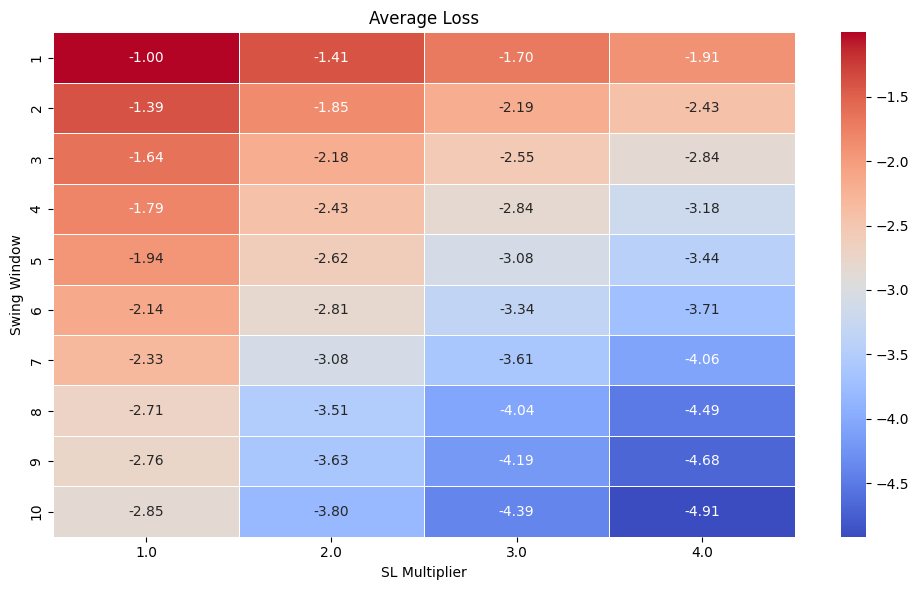

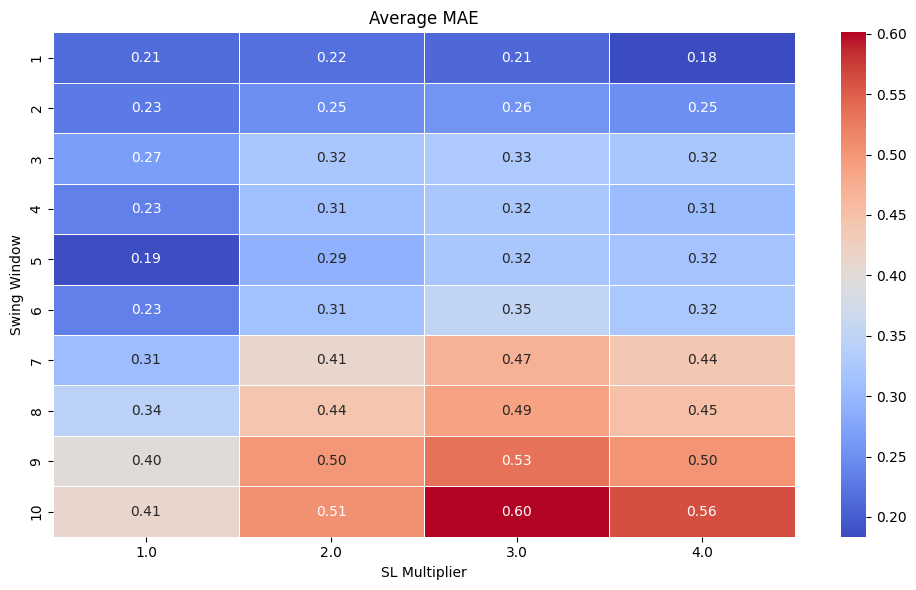

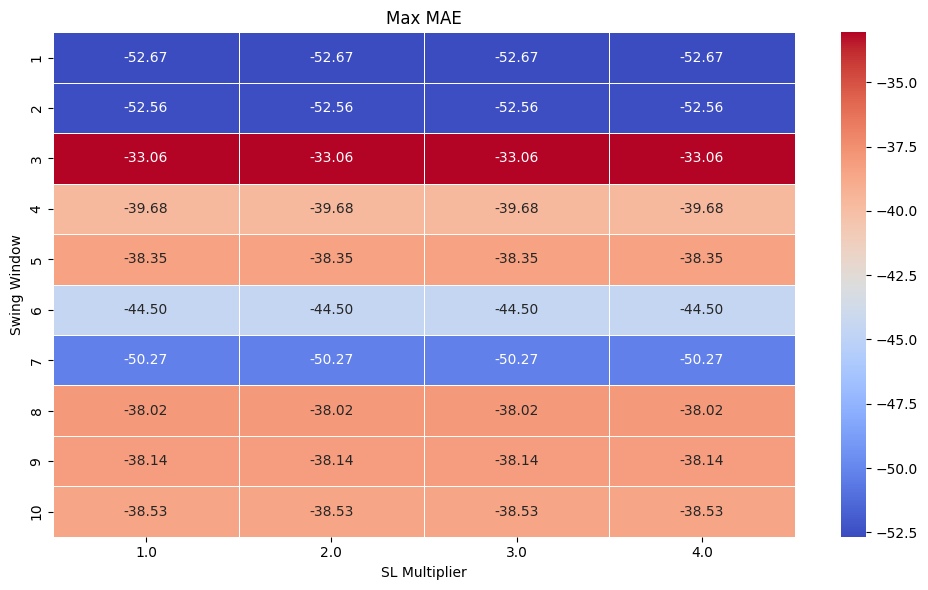

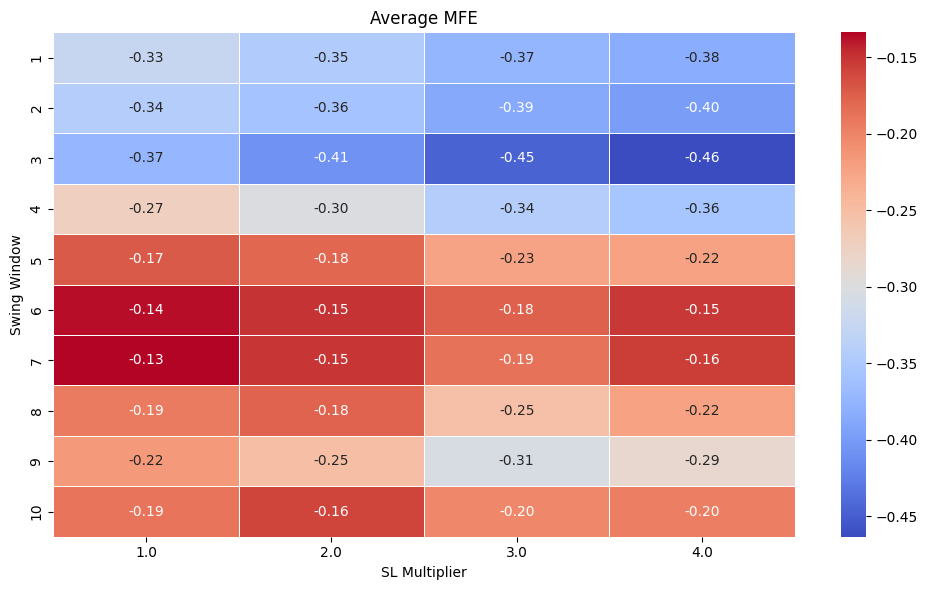

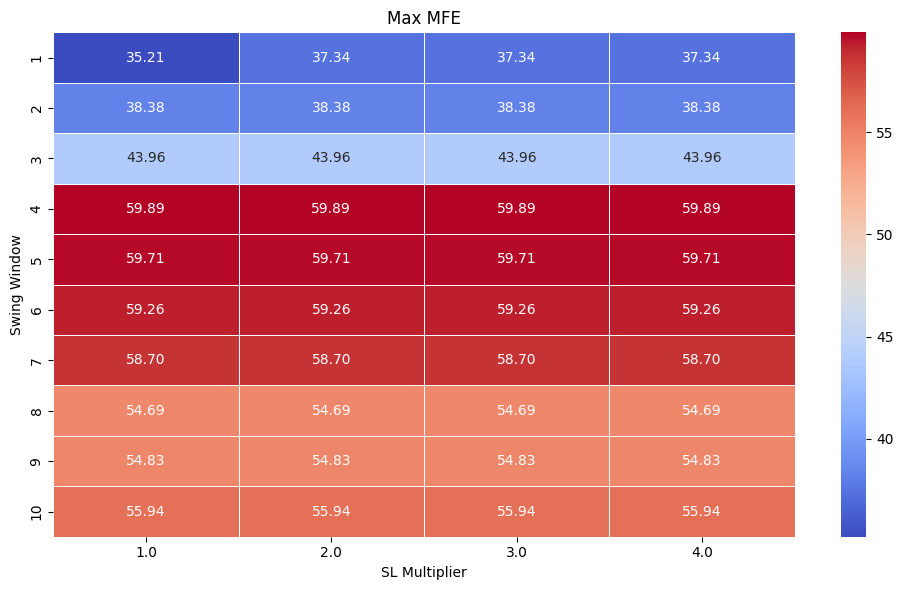

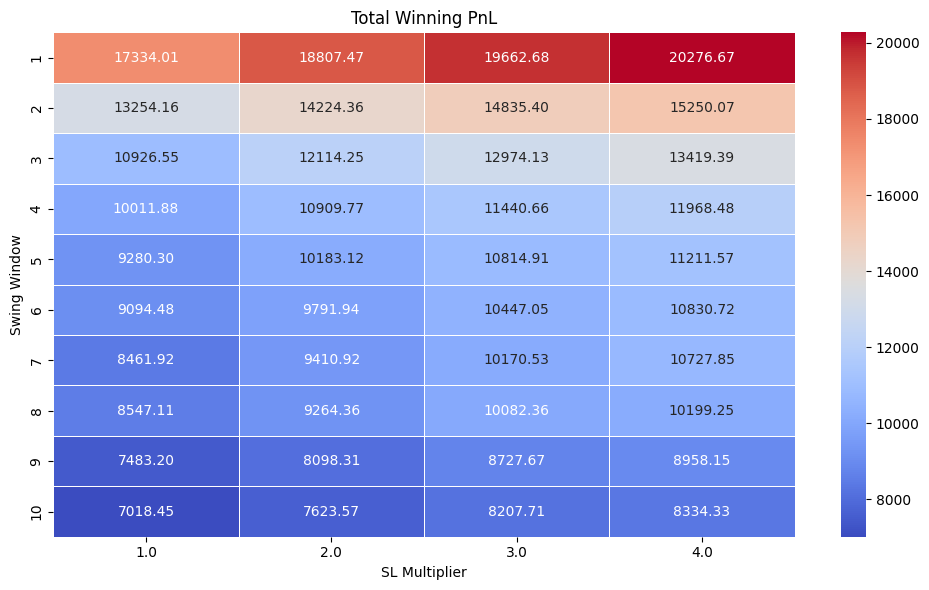

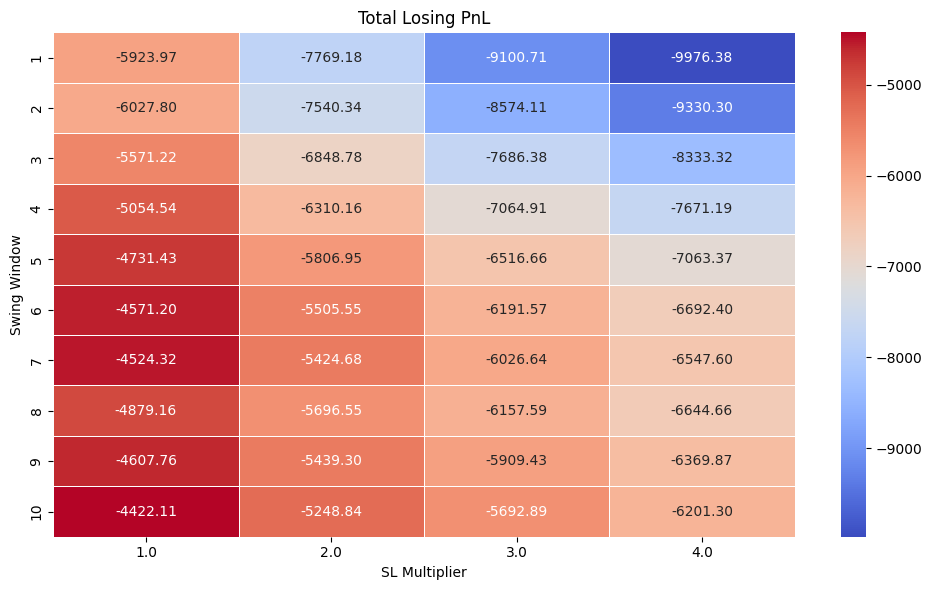

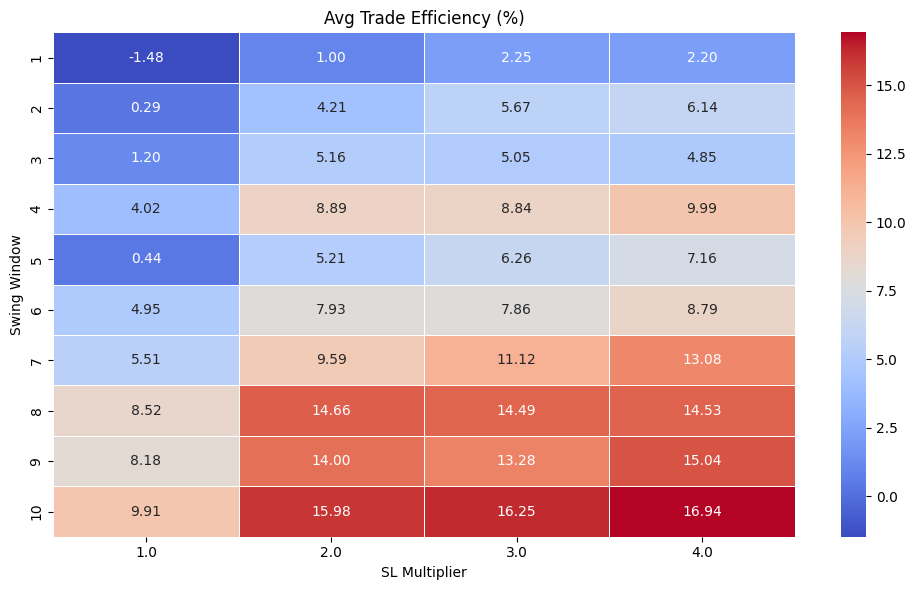

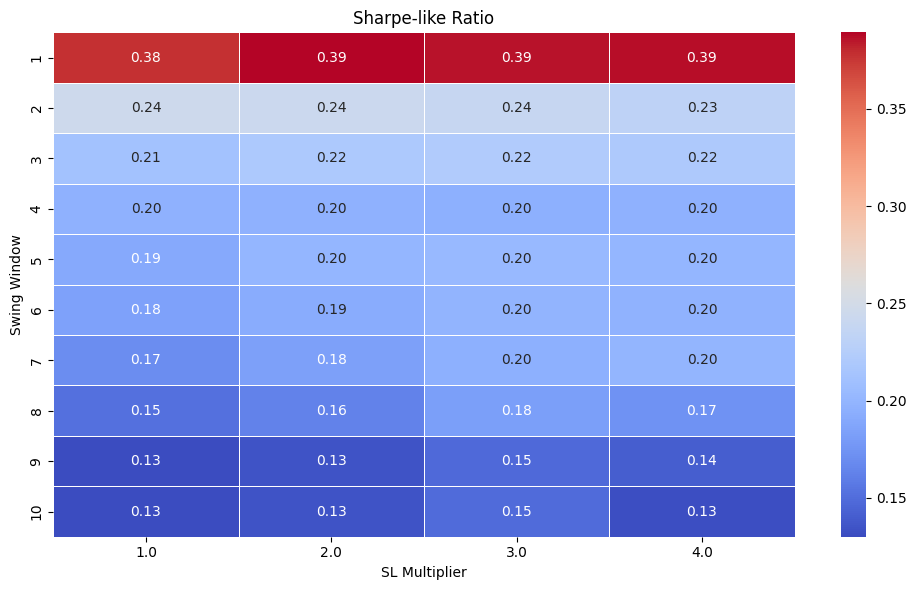

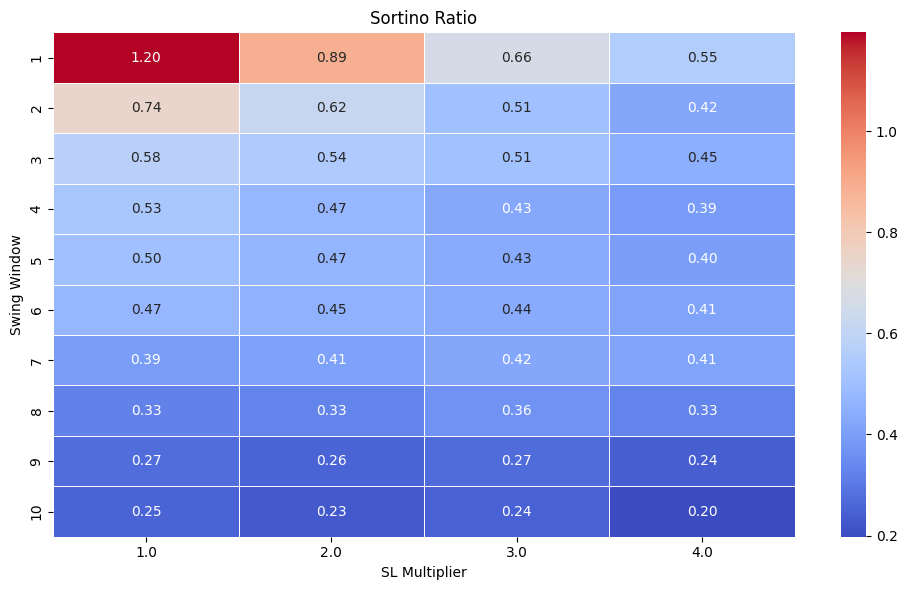

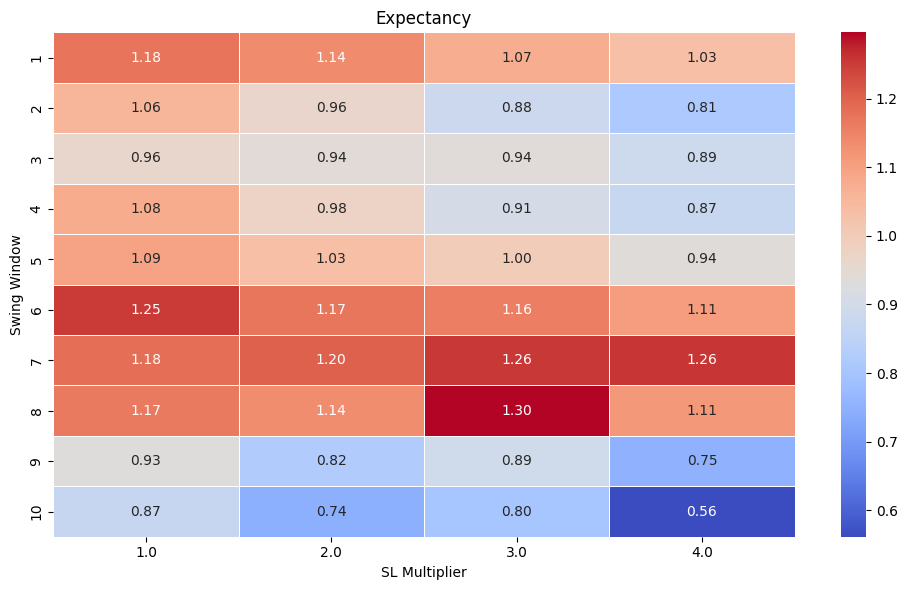

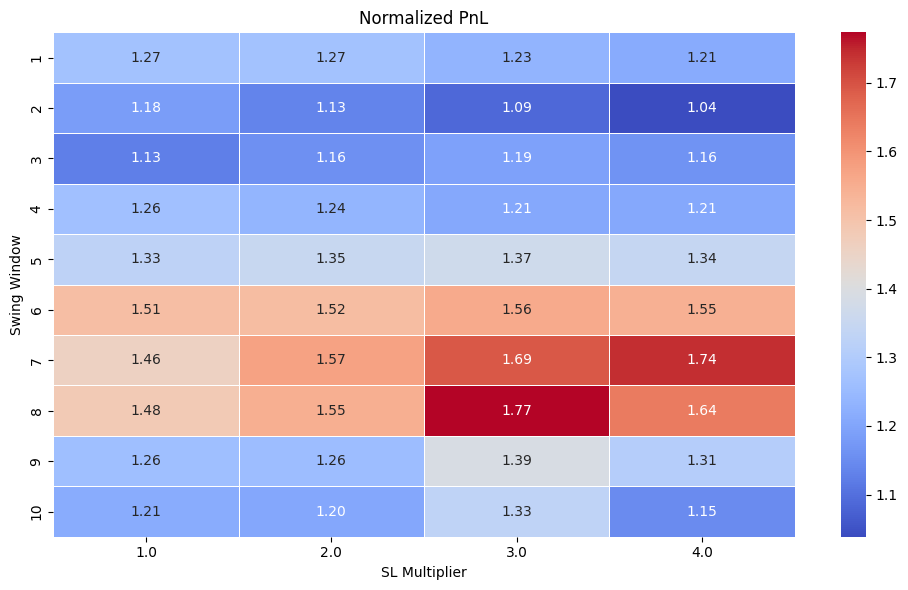

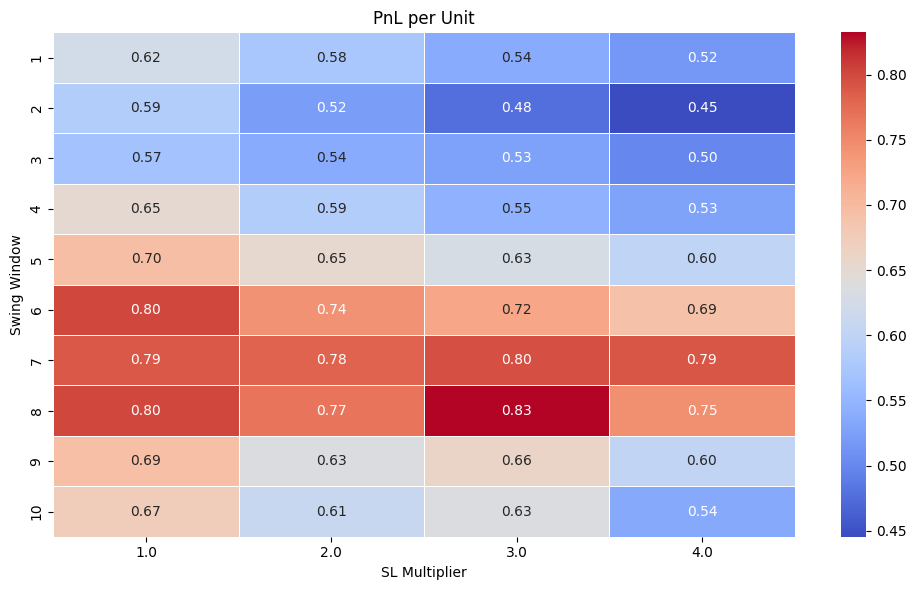

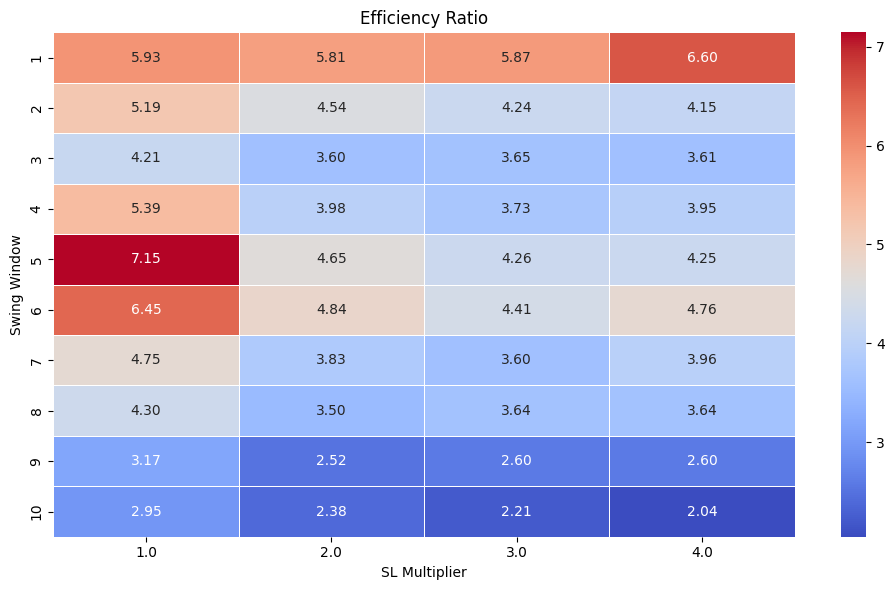

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
summary_path = r"Parameters Comparison Summary/summary_results_entry_on_either_two_candles.csv"
df = pd.read_csv(summary_path)

# Function to plot a heatmap for a given metric
def plot_heatmap(metric, title, cmap='coolwarm', fmt='.2f'):
    pivot = df.pivot(index="Window", columns="SL Multiplier", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5)
    plt.title(title)
    plt.xlabel("SL Multiplier")
    plt.ylabel("Swing Window")
    plt.tight_layout()
    plt.show()

# List of metrics and corresponding titles
metrics_to_plot = [
    ("Total Trades", "Total Trades"),
    ("Win Rate (%)", "Win Rate (%)"),
    ("Total PnL", "Total PnL"),
    ("Average PnL", "Average PnL"),
    ("Max Drawdown", "Max Drawdown"),
    ("Risk-Reward", "Risk-Reward Ratio"),
    ("Avg Win", "Average Win"),
    ("Avg Loss", "Average Loss"),
    ("Average MAE", "Average MAE"),
    ("Max MAE", "Max MAE"),
    ("Average MFE", "Average MFE"),
    ("Max MFE", "Max MFE"),
    ("Winning PnL", "Total Winning PnL"),
    ("Losing PnL", "Total Losing PnL"),
    ("Avg Trade Efficiency (%)", "Avg Trade Efficiency (%)"),
    ("Sharpe-like Ratio", "Sharpe-like Ratio"),
    ("Sortino Ratio", "Sortino Ratio"),
    ("Expectancy", "Expectancy"),
    ("Normalized PnL", "Normalized PnL"),
    ("PnL per Unit", "PnL per Unit"),
    ("Efficiency Ratio", "Efficiency Ratio"),
]

# Generate heatmaps
for metric, title in metrics_to_plot:
    plot_heatmap(metric, title)



In [39]:
import os
import glob
import numpy as np
import pandas as pd

# Safe division to avoid divide-by-zero issues
def safe_divide(a, b):
    return a / b if b != 0 else np.nan

# Folder containing all your trade result CSVs
trades_folder = 'all_trades_entry_on_either_two_candles'
pattern = os.path.join(trades_folder, "All_Trades_Window_*_SL_*.csv")

summary_rows = []

for file in glob.glob(pattern):
    filename = os.path.basename(file)
    parts = filename.replace(".csv", "").split("_")
    window = int(parts[3])
    sl_mult = float(parts[5])
    
    df = pd.read_csv(file)
    if df.empty:
        print(f'window = {window} and sl =  {sl_mult} file not found')
        continue

    total_trades = len(df)
    win_trades = (df['PnL'] > 0).sum()
    win_rate = win_trades / total_trades * 100
    total_pnl = df['PnL'].sum()
    avg_pnl = df['PnL'].mean()
    max_drawdown = (df['Cumulative PnL'].cummax() - df['Cumulative PnL']).max()
    avg_win = df.loc[df['PnL'] > 0, 'PnL'].mean()
    avg_loss = df.loc[df['PnL'] < 0, 'PnL'].mean()
    rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
    avg_mae = df['MAE'].mean()
    max_mae = df['MAE'].min()
    avg_mfe = df['MFE'].mean()
    max_mfe = df['MFE'].max()
    winning_pnl = df.loc[df['PnL'] > 0, 'PnL'].sum()
    losing_pnl = df.loc[df['PnL'] < 0, 'PnL'].sum()
    efficiency = (df['PnL'] / df['MFE'].replace(0, float('nan'))) * 100
    avg_efficiency = efficiency.mean()
    total_units = df['Units'].sum()

    # Derived Metrics
    sharpe_like = safe_divide(avg_pnl, np.std([avg_win, abs(avg_loss)]))
    expectancy = (win_rate / 100) * avg_win + (1 - win_rate / 100) * avg_loss
    normalized_pnl = safe_divide(total_pnl, total_trades)
    pnl_per_unit = safe_divide(total_pnl, total_units)
    efficiency_ratio = safe_divide(avg_pnl, abs(avg_mae))

    # True Downside Deviation (for Sortino)
    downside_returns = df[df['PnL'] < 0]['PnL']
    downside_deviation = downside_returns.std() if not downside_returns.empty else 0
    sortino_ratio = safe_divide(avg_pnl, downside_deviation)

    summary_rows.append({
        'Window': window,
        'SL Multiplier': sl_mult,
        'Total Trades': total_trades,
        'Total Units': total_units,
        'Win Rate (%)': win_rate,
        'Total PnL': total_pnl,
        'Average PnL': avg_pnl,
        'Max Drawdown': max_drawdown,
        'Risk-Reward': rr,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
        'Average MAE': avg_mae,
        'Max MAE': max_mae,
        'Average MFE': avg_mfe,
        'Max MFE': max_mfe,
        'Winning PnL': winning_pnl,
        'Losing PnL': losing_pnl,
        'Avg Trade Efficiency (%)': avg_efficiency,
        'Sharpe-like Ratio': sharpe_like,
        'Sortino Ratio': sortino_ratio,
        'Expectancy': expectancy,
        'Normalized PnL': normalized_pnl,
        'PnL per Unit': pnl_per_unit,
        'Efficiency Ratio': efficiency_ratio
    })

# Save to summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_output_path = r"C:\Users\A\epat\Algo Project\Python-Projects\Parameters Comparison Summary\summary_results_entry_on_either_two_candles.csv"
summary_df.to_csv(summary_output_path, index=False)
print("✅ Final summary saved to summary_results_entry_on_either_two_candles.csv with all key metrics.")


✅ Final summary saved to summary_results_entry_on_either_two_candles.csv with all key metrics.


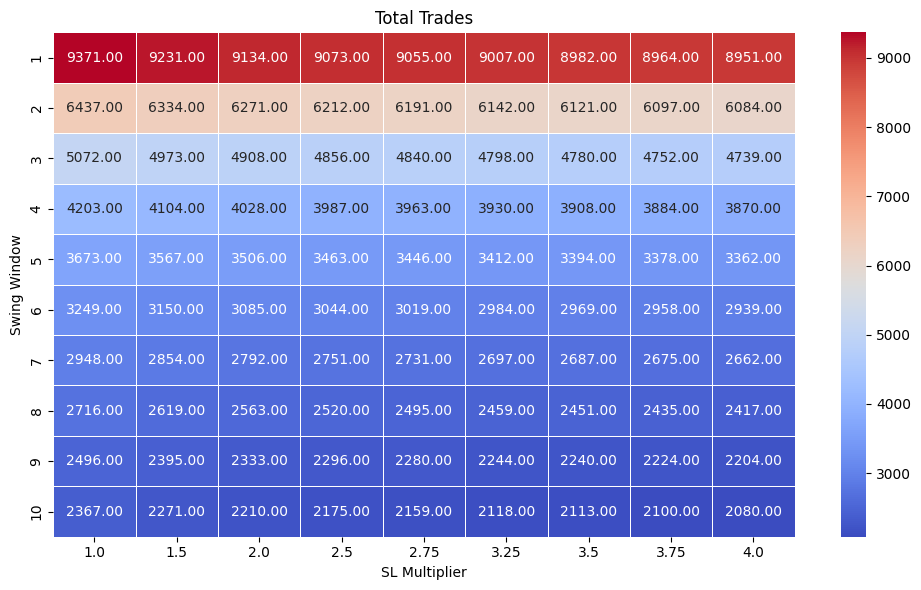

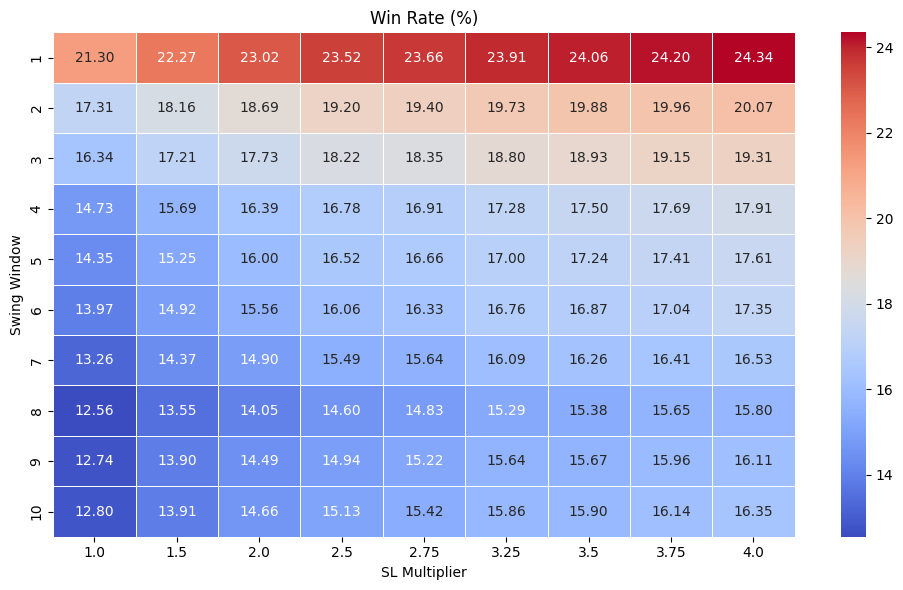

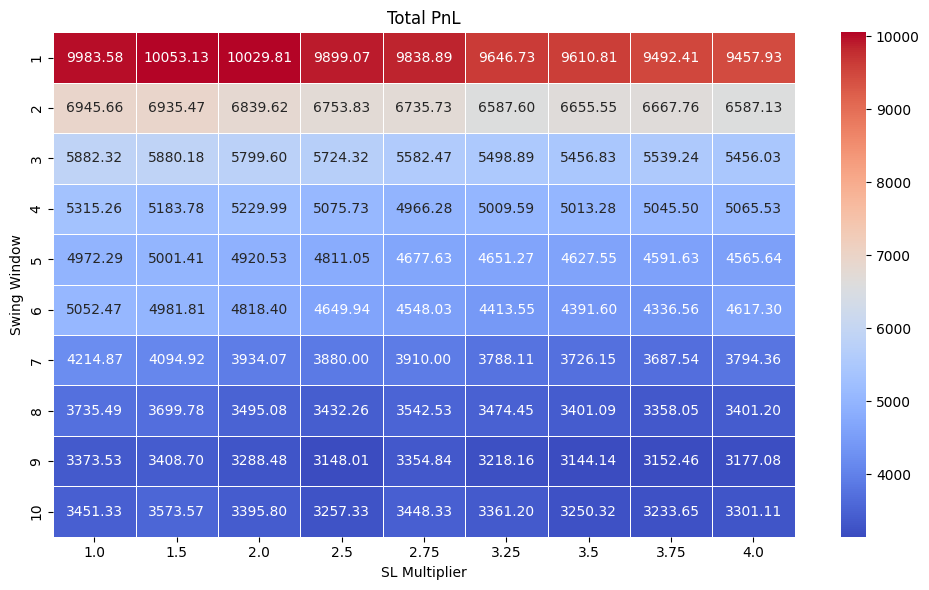

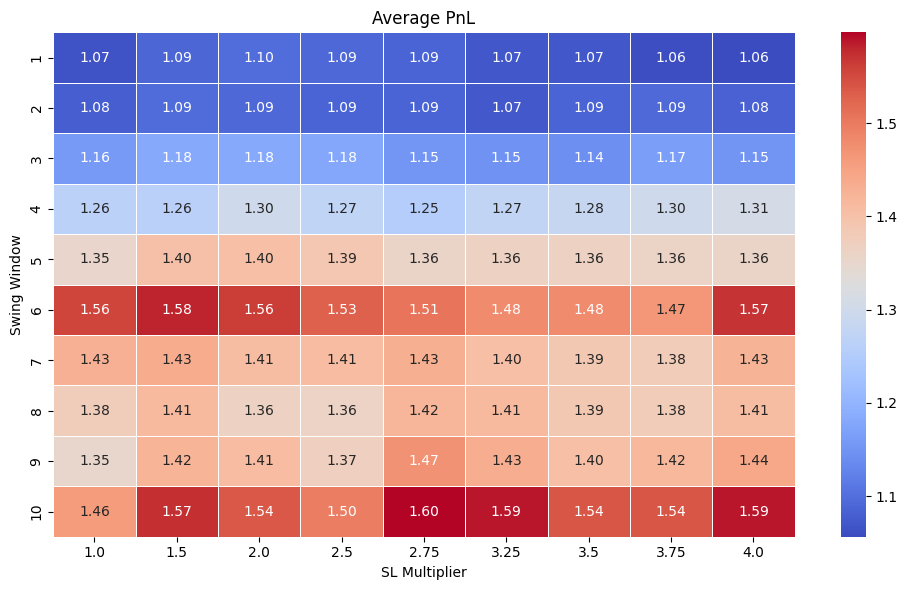

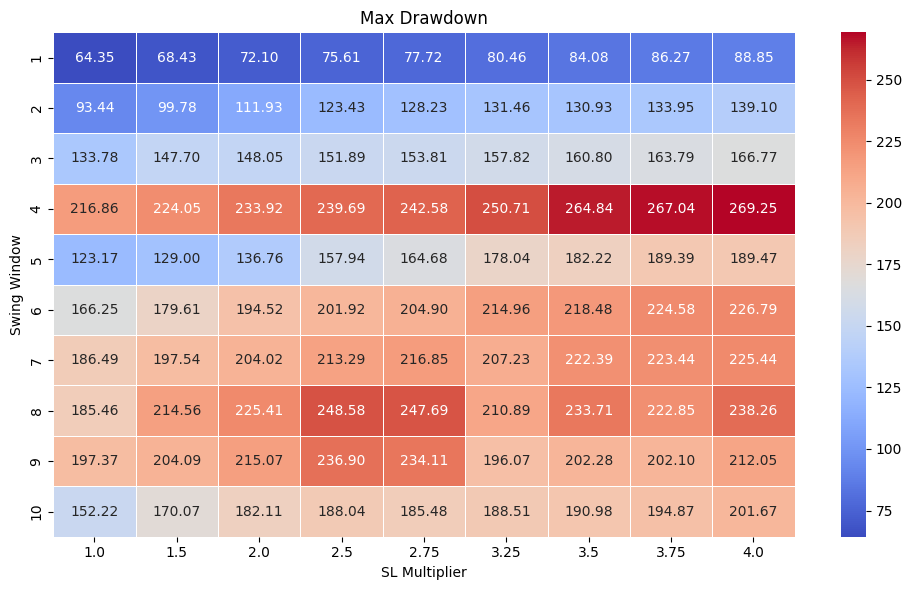

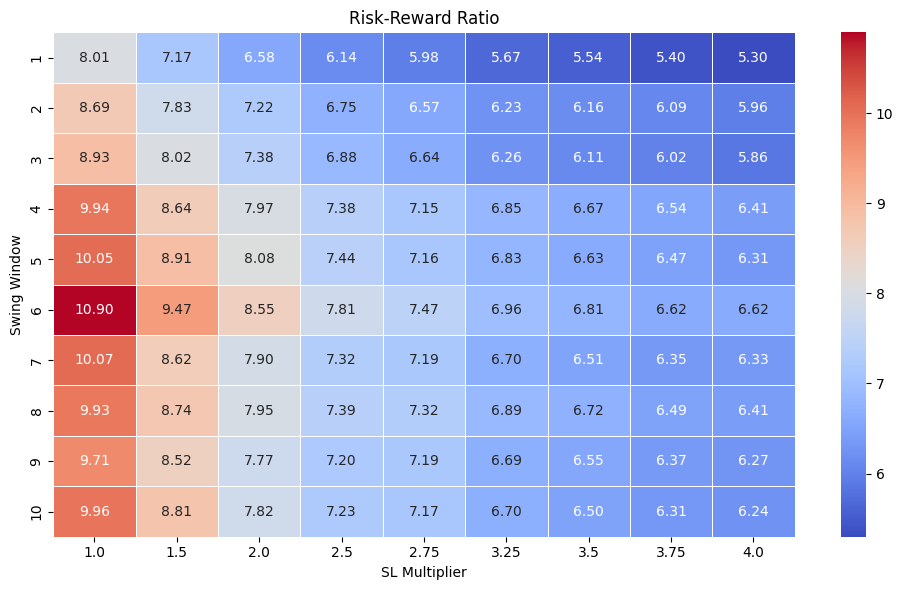

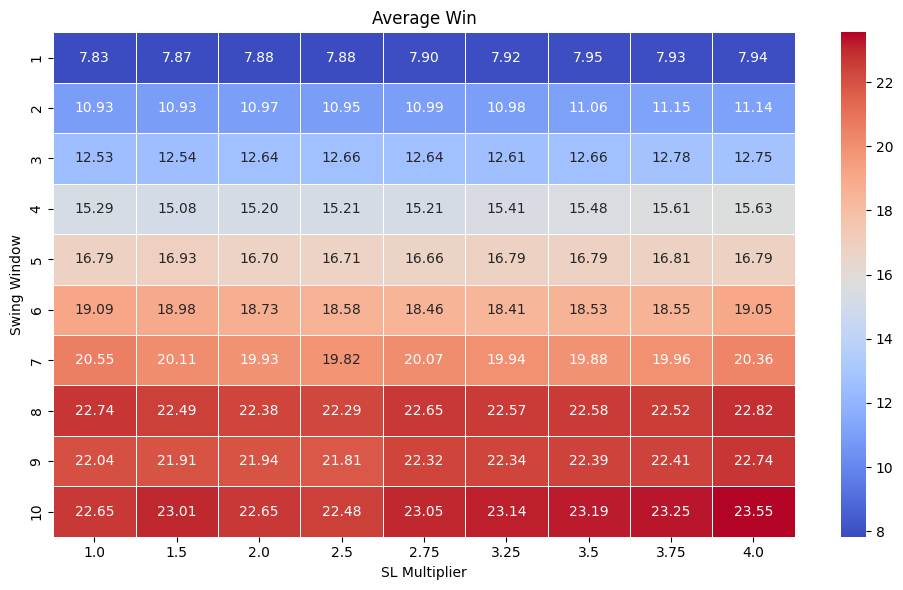

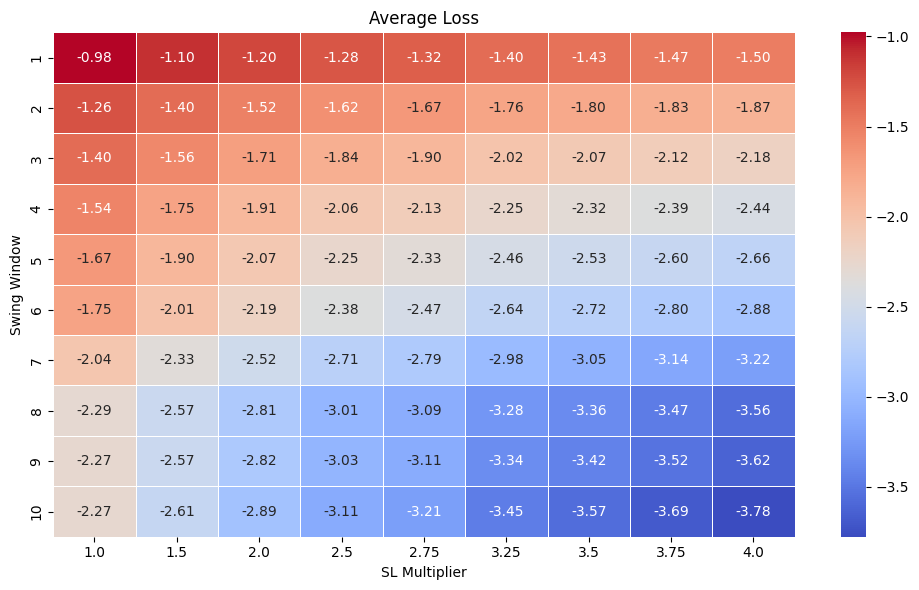

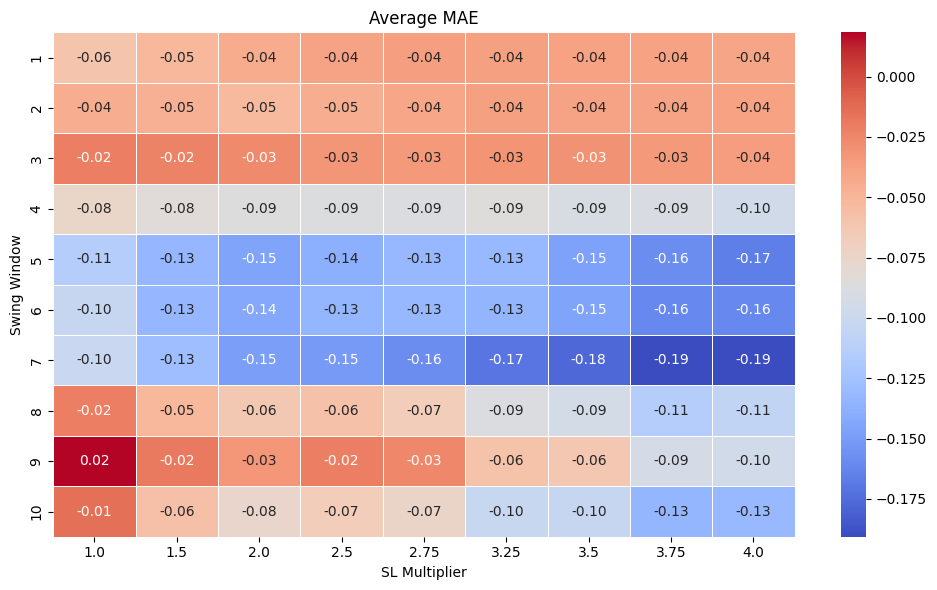

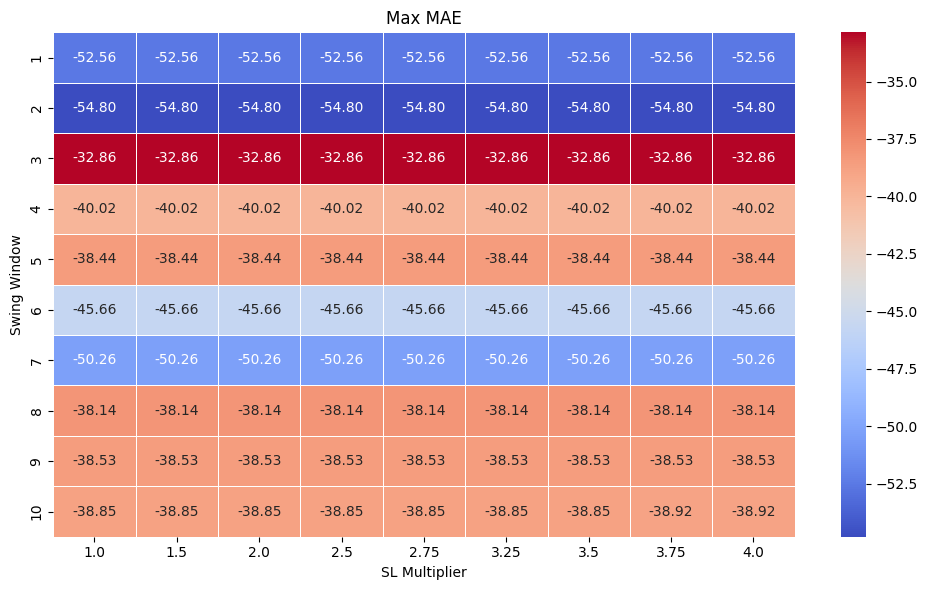

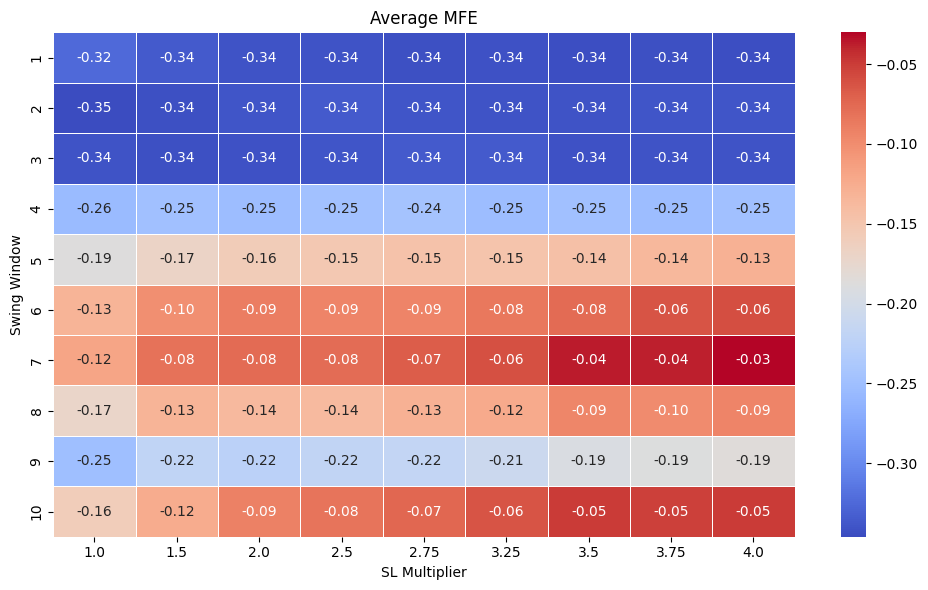

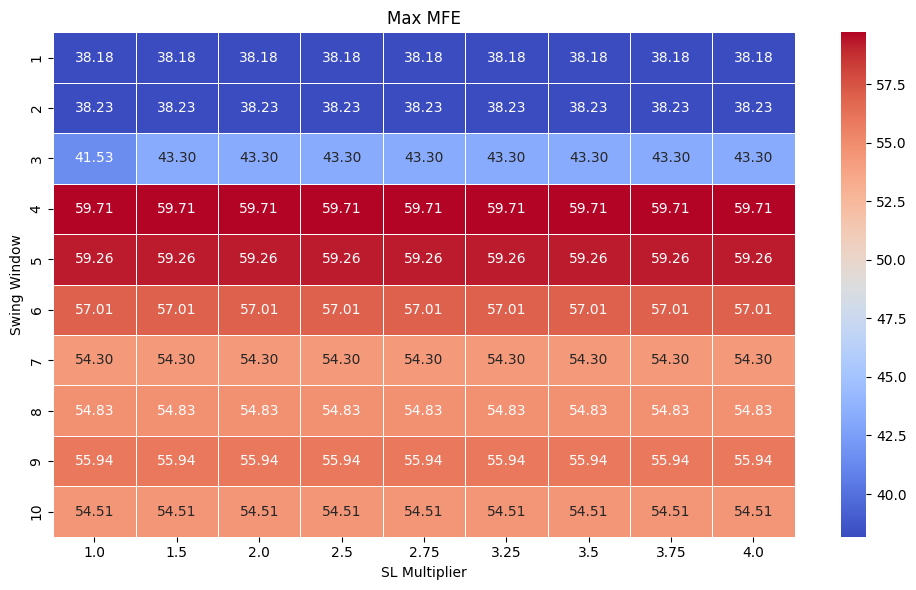

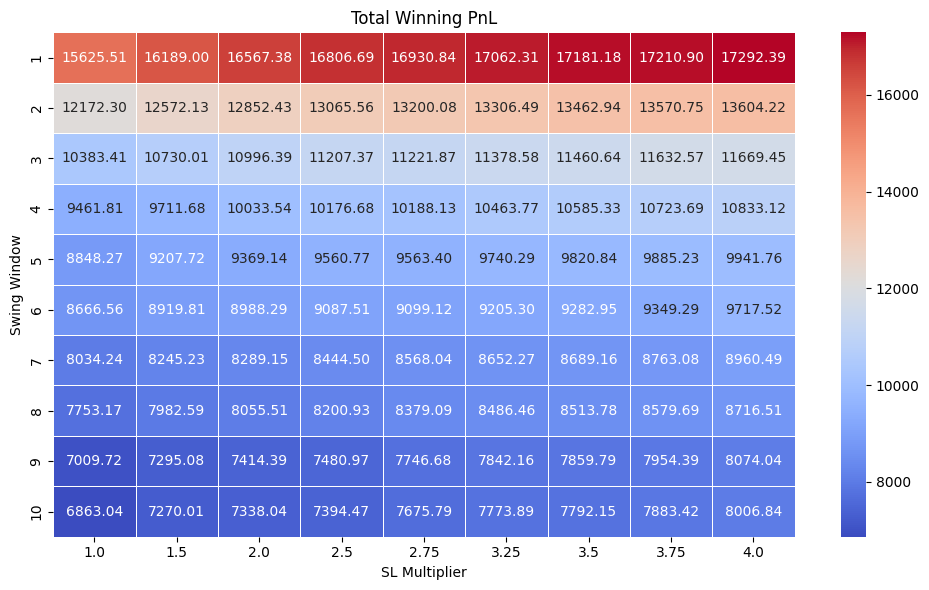

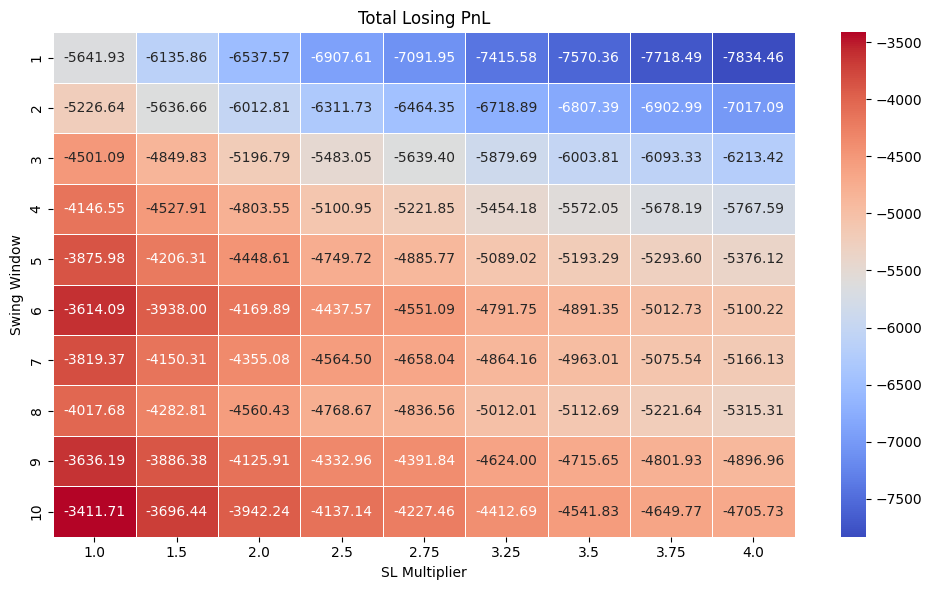

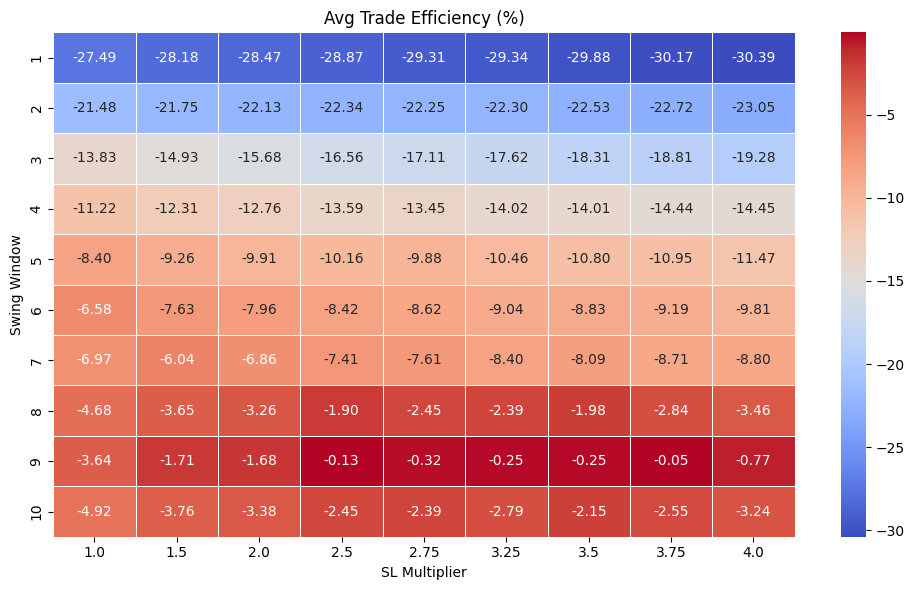

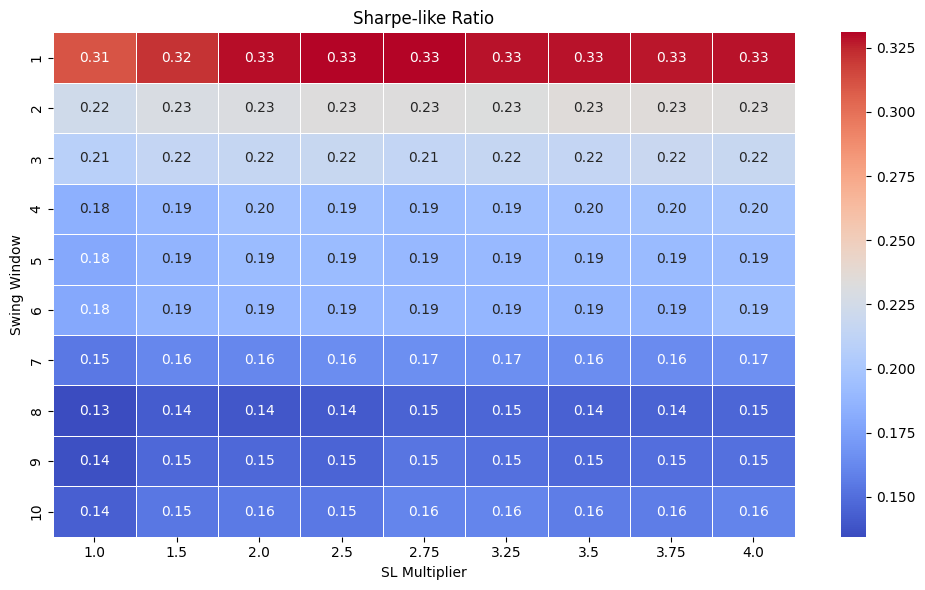

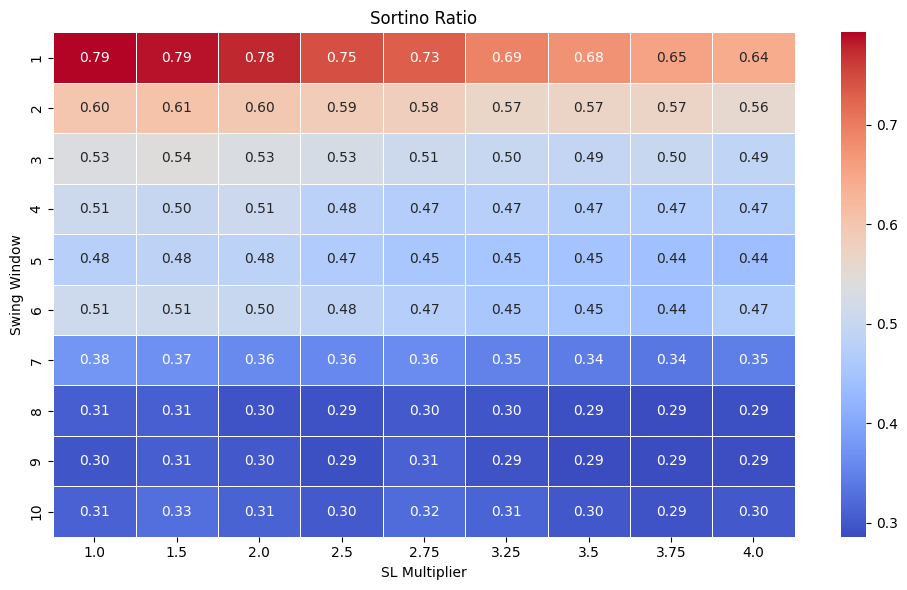

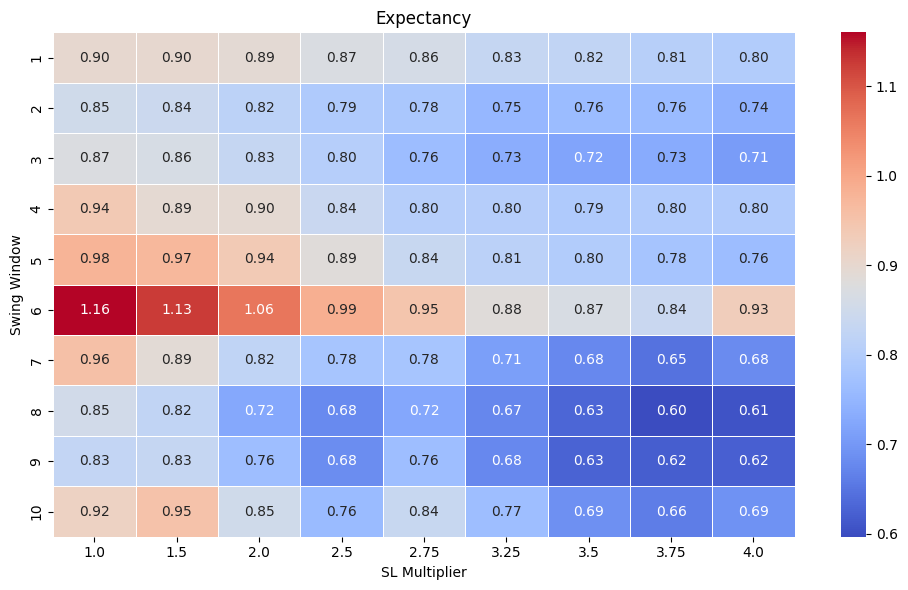

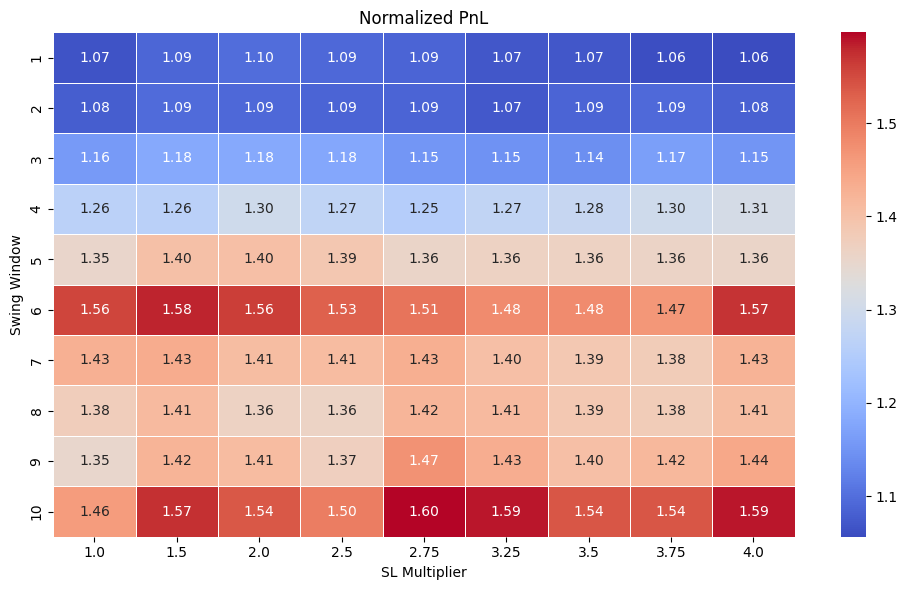

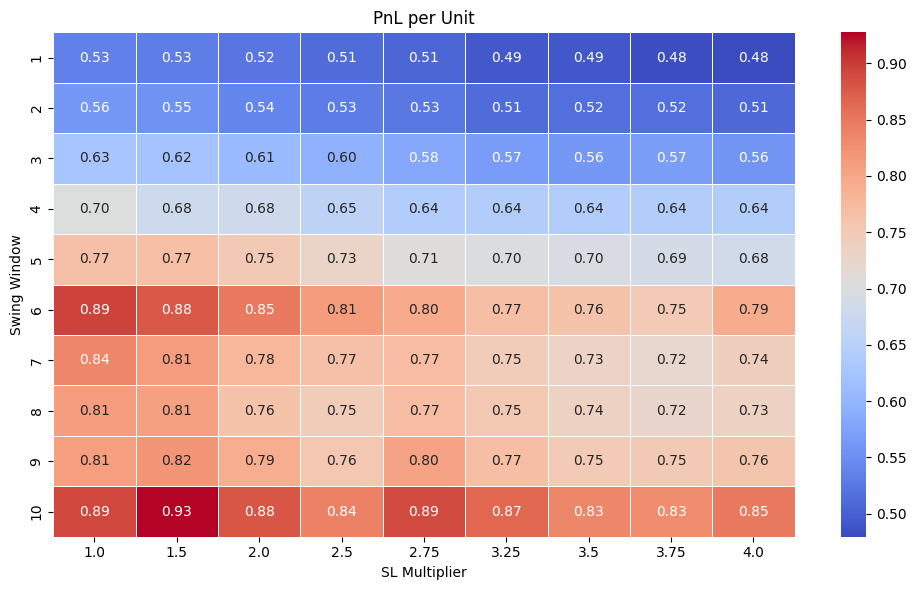

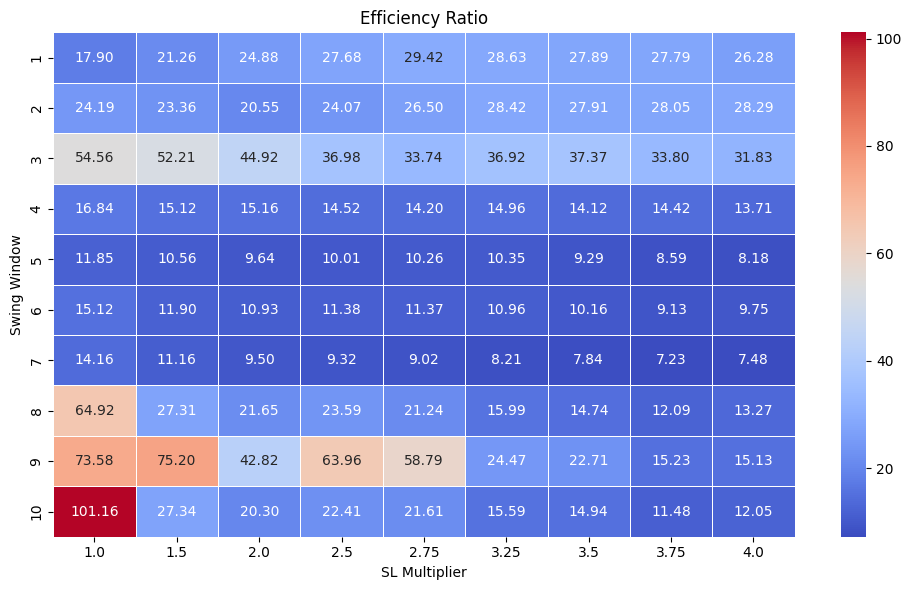

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
summary_path = r"Parameters Comparison Summary/summary_results_entry_on_either_two_candles.csv"
df = pd.read_csv(summary_path)

# Function to plot a heatmap for a given metric
def plot_heatmap(metric, title, cmap='coolwarm', fmt='.2f'):
    pivot = df.pivot(index="Window", columns="SL Multiplier", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5)
    plt.title(title)
    plt.xlabel("SL Multiplier")
    plt.ylabel("Swing Window")
    plt.tight_layout()
    plt.show()

# List of metrics and corresponding titles
metrics_to_plot = [
    ("Total Trades", "Total Trades"),
    ("Win Rate (%)", "Win Rate (%)"),
    ("Total PnL", "Total PnL"),
    ("Average PnL", "Average PnL"),
    ("Max Drawdown", "Max Drawdown"),
    ("Risk-Reward", "Risk-Reward Ratio"),
    ("Avg Win", "Average Win"),
    ("Avg Loss", "Average Loss"),
    ("Average MAE", "Average MAE"),
    ("Max MAE", "Max MAE"),
    ("Average MFE", "Average MFE"),
    ("Max MFE", "Max MFE"),
    ("Winning PnL", "Total Winning PnL"),
    ("Losing PnL", "Total Losing PnL"),
    ("Avg Trade Efficiency (%)", "Avg Trade Efficiency (%)"),
    ("Sharpe-like Ratio", "Sharpe-like Ratio"),
    ("Sortino Ratio", "Sortino Ratio"),
    ("Expectancy", "Expectancy"),
    ("Normalized PnL", "Normalized PnL"),
    ("PnL per Unit", "PnL per Unit"),
    ("Efficiency Ratio", "Efficiency Ratio"),
]

# Generate heatmaps
for metric, title in metrics_to_plot:
    plot_heatmap(metric, title)



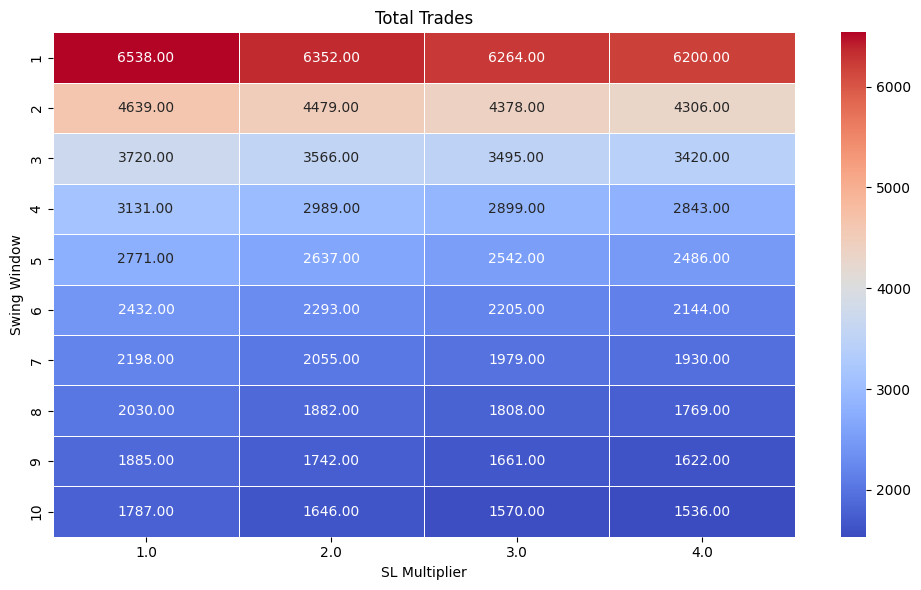

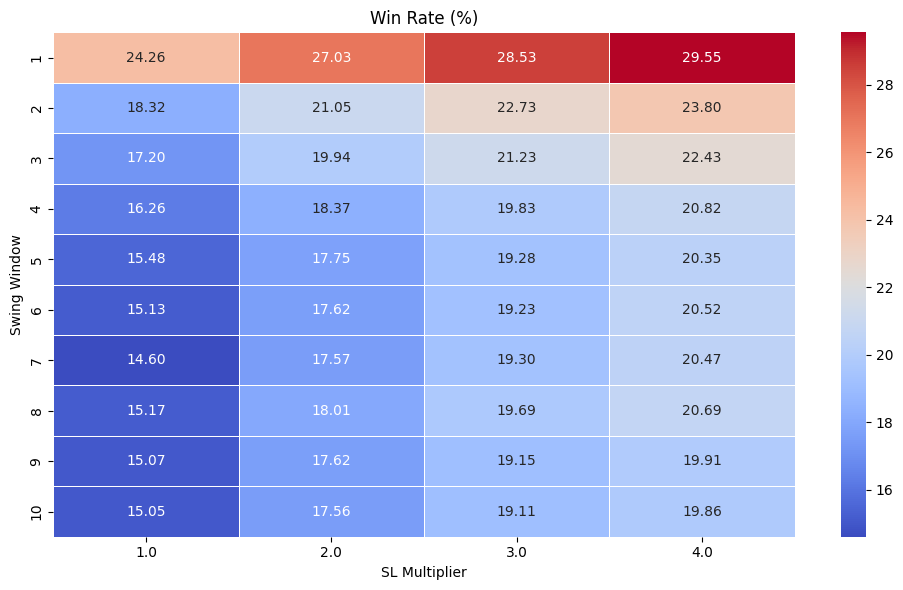

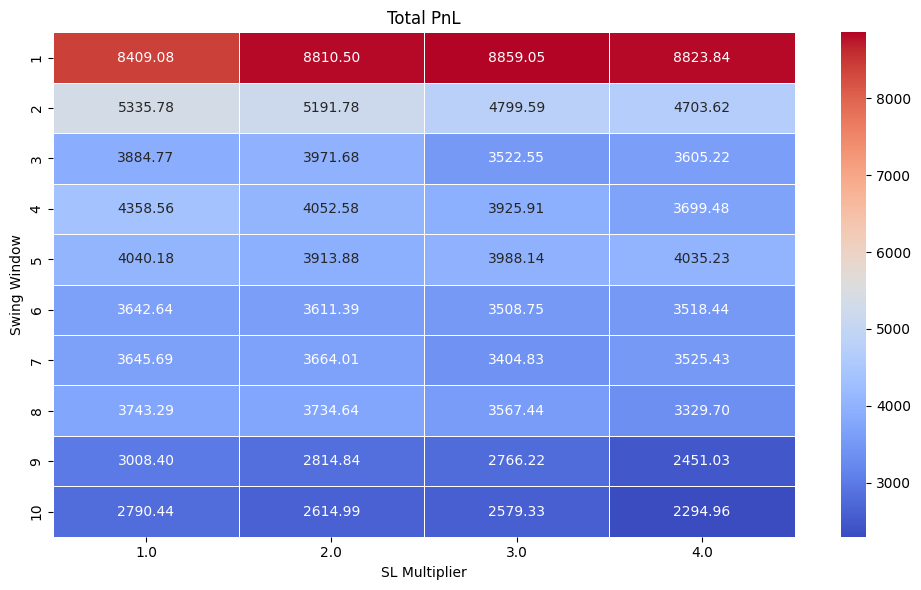

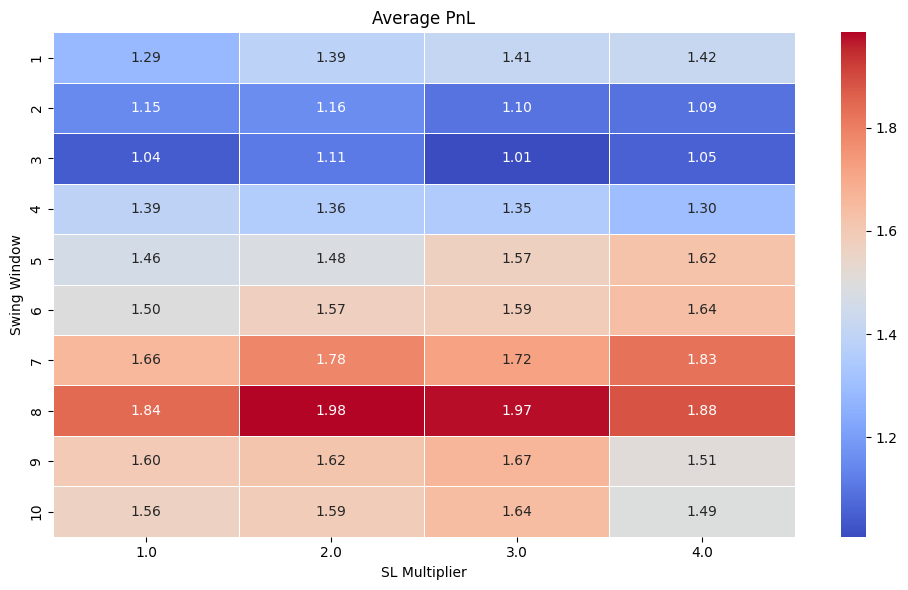

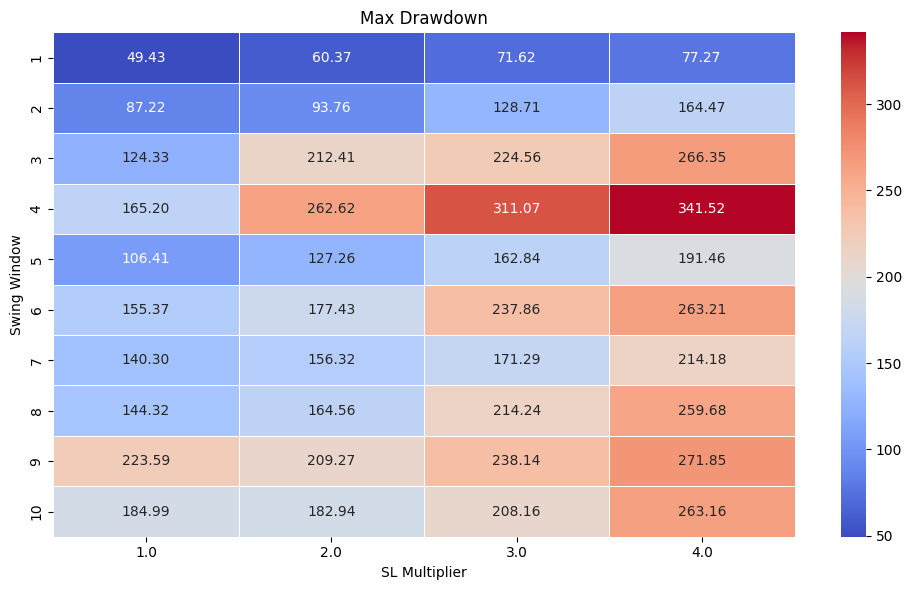

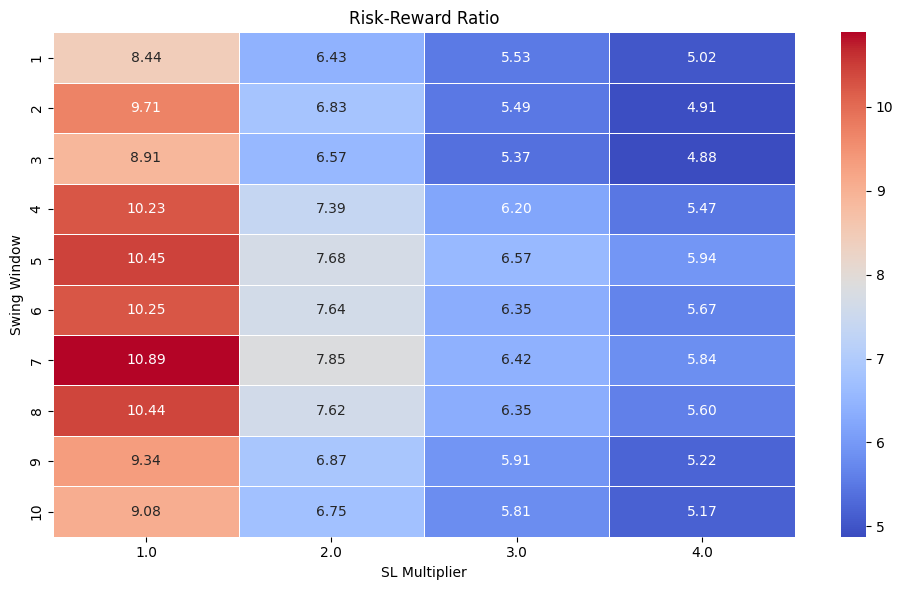

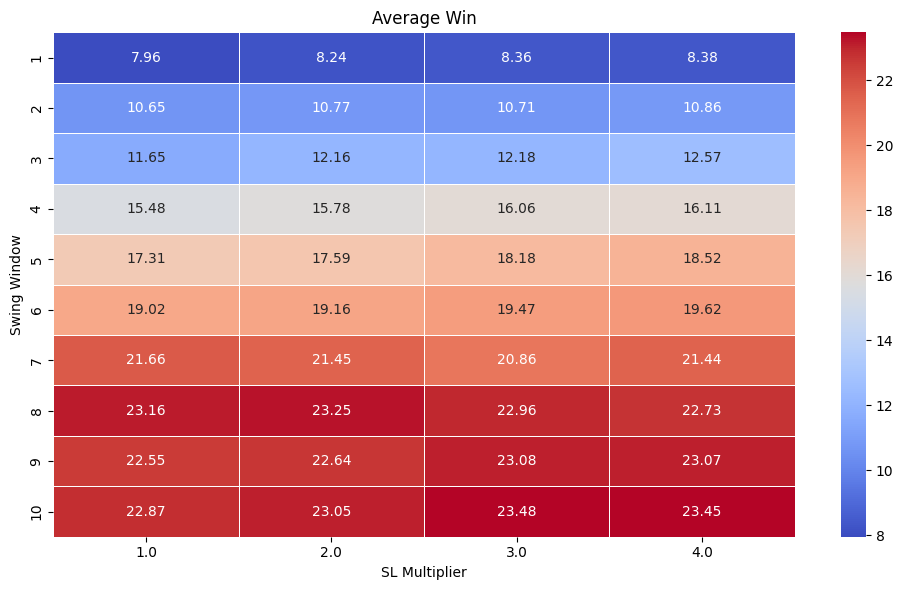

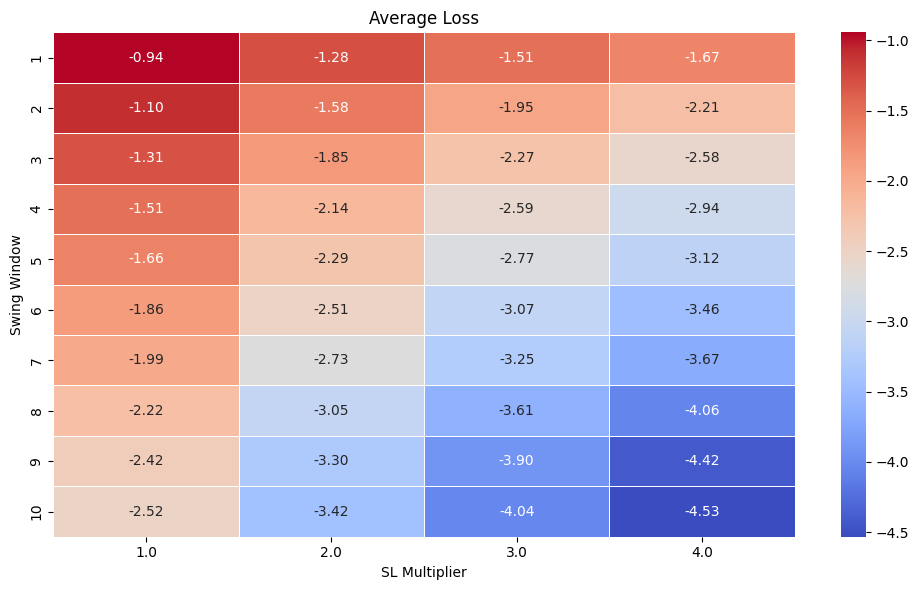

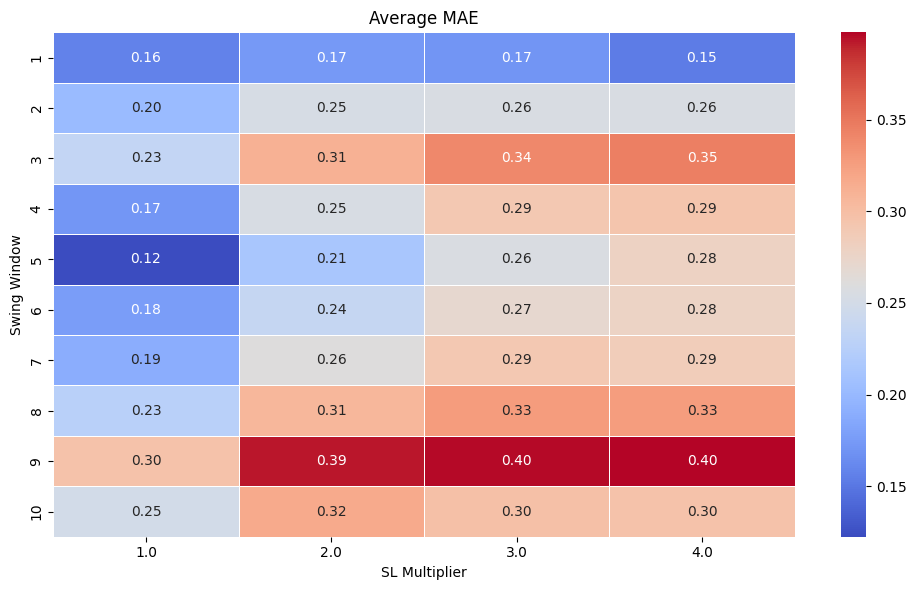

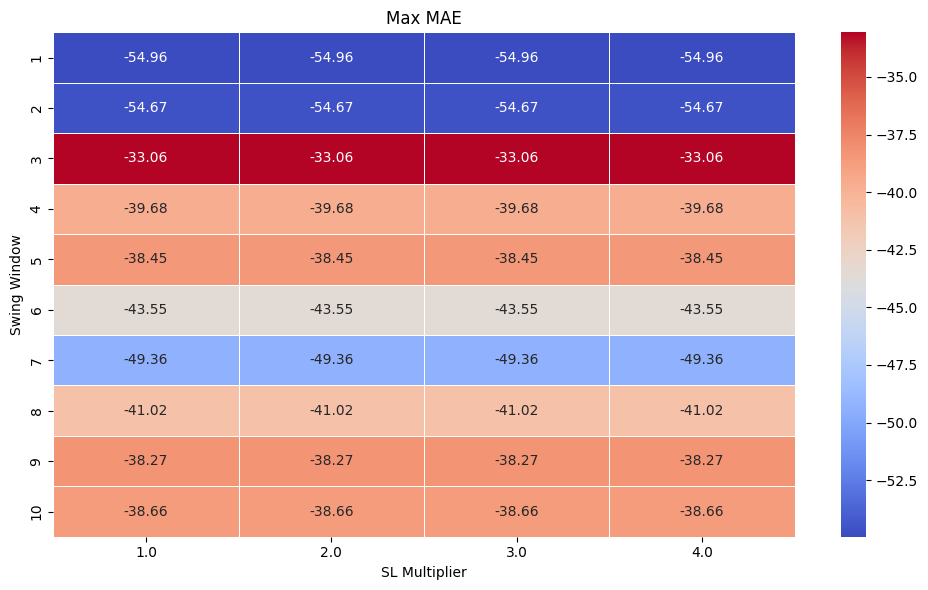

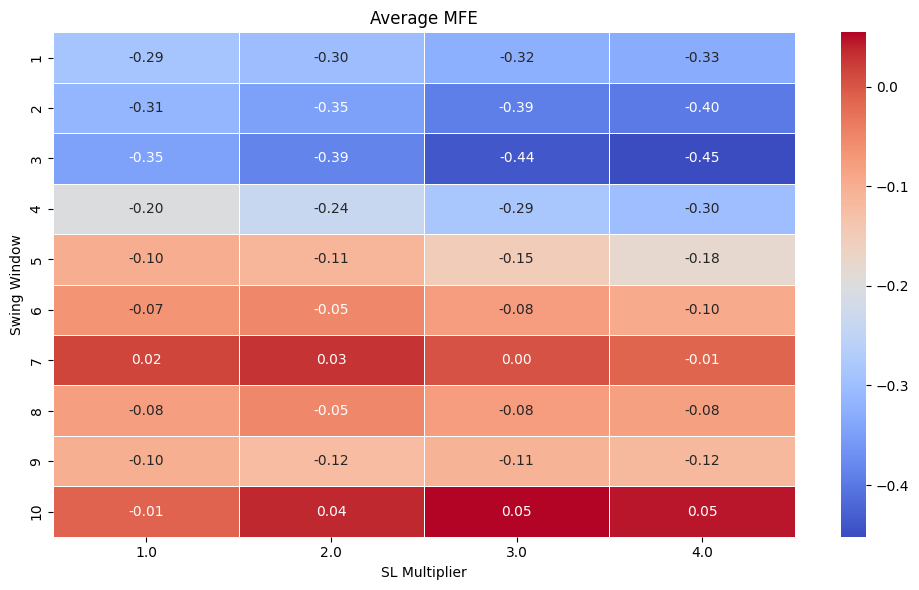

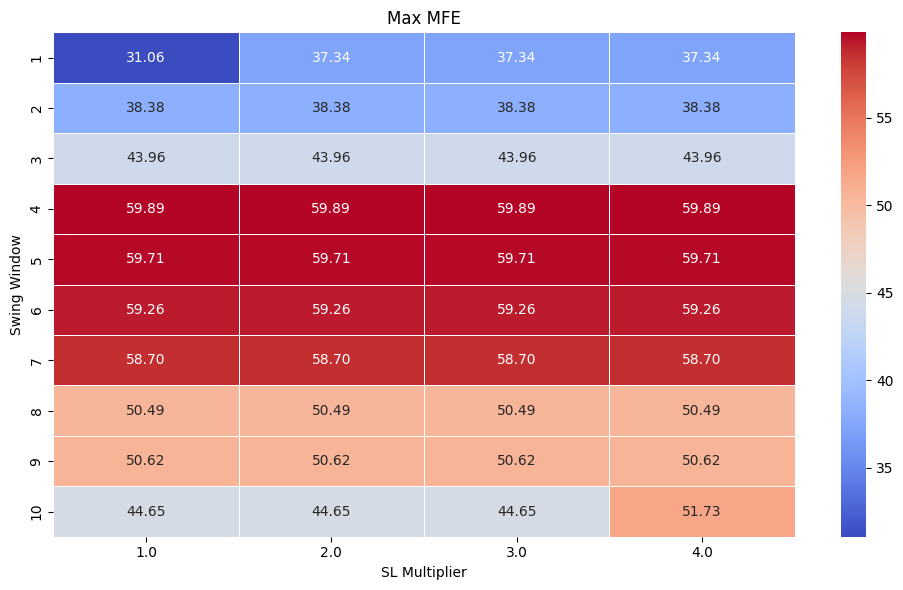

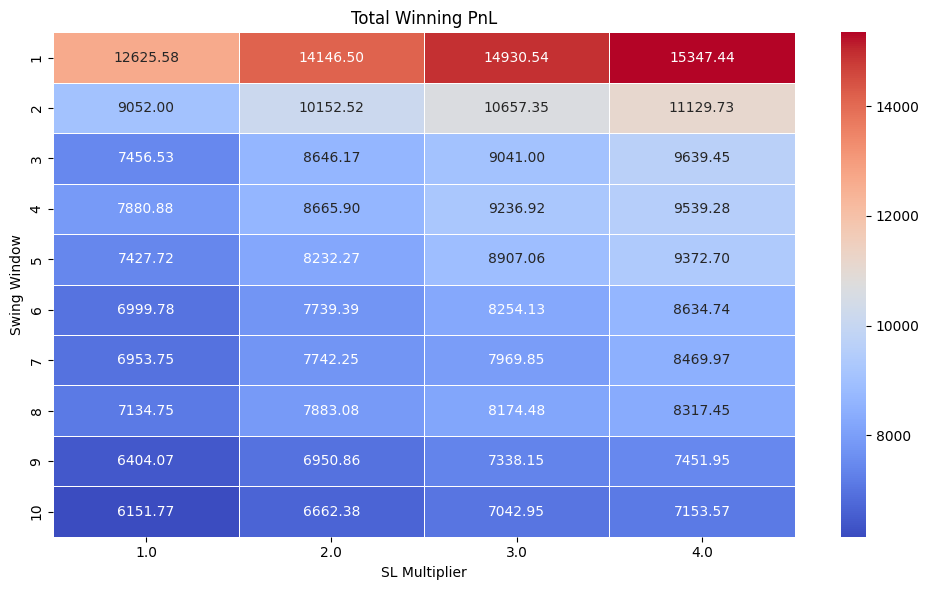

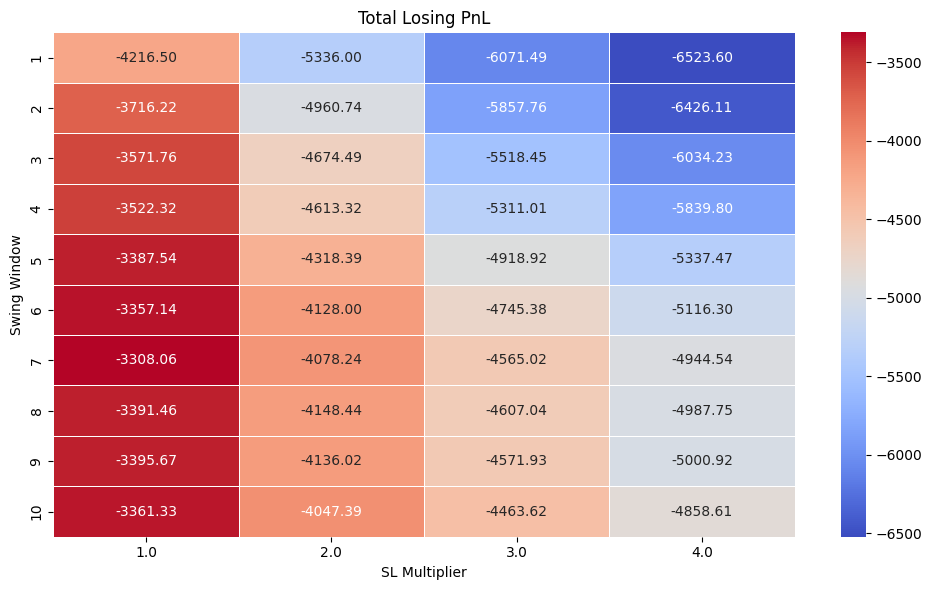

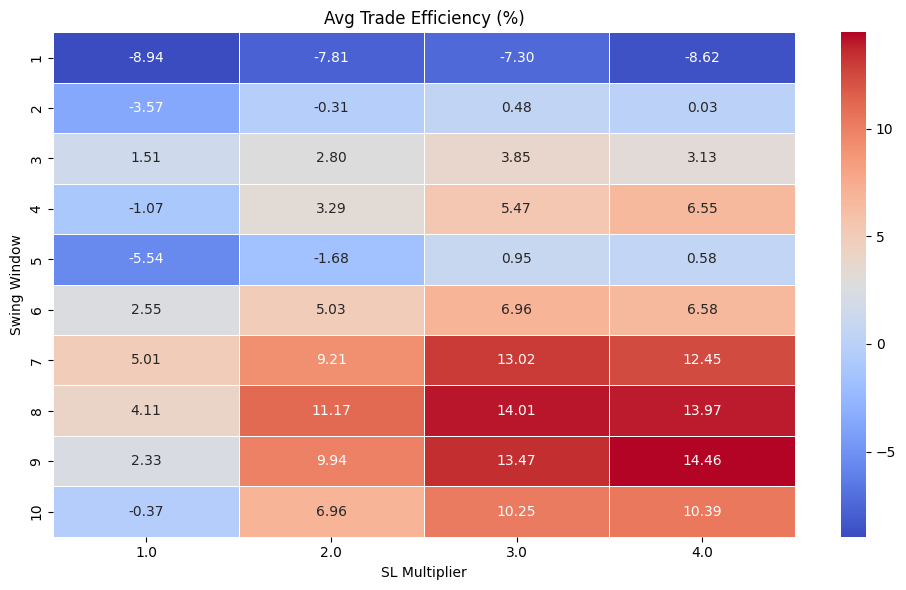

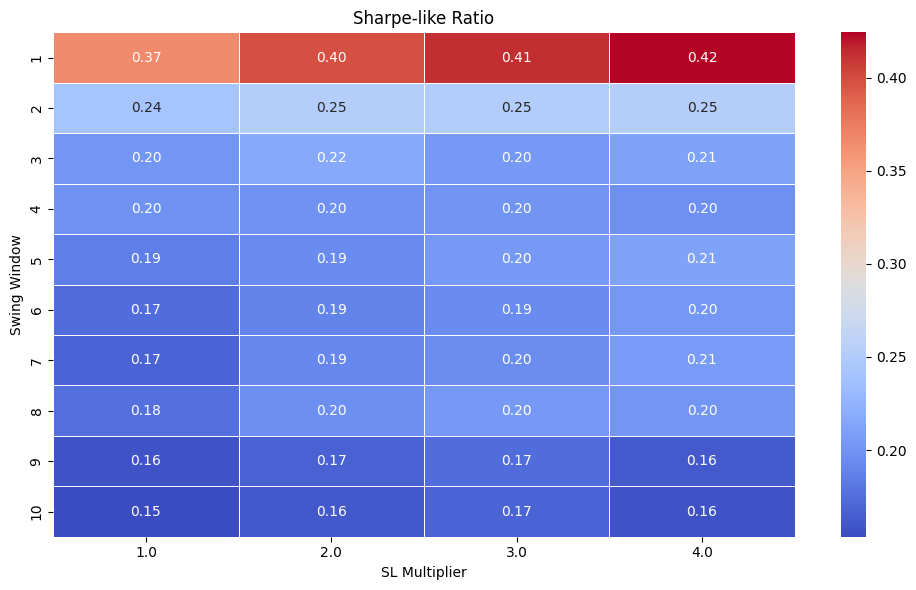

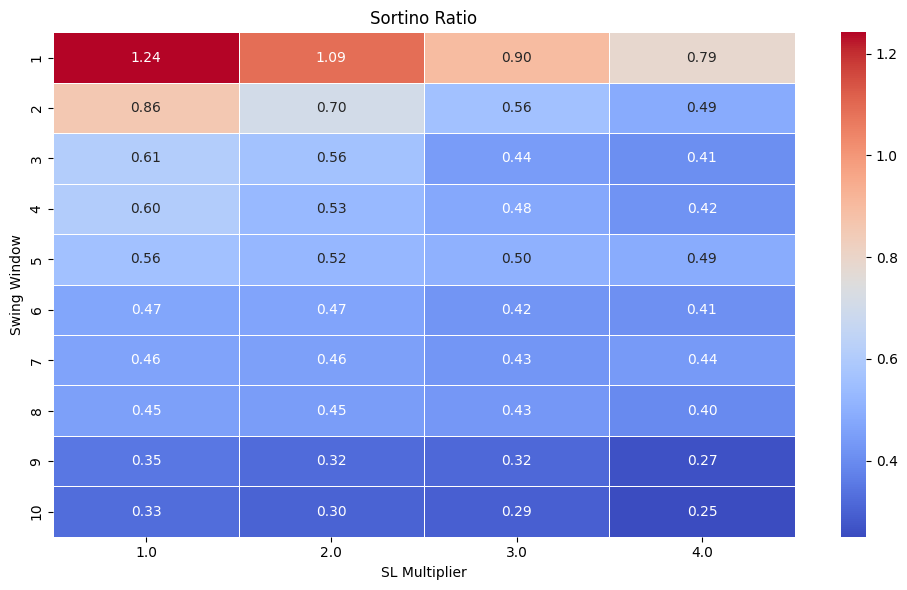

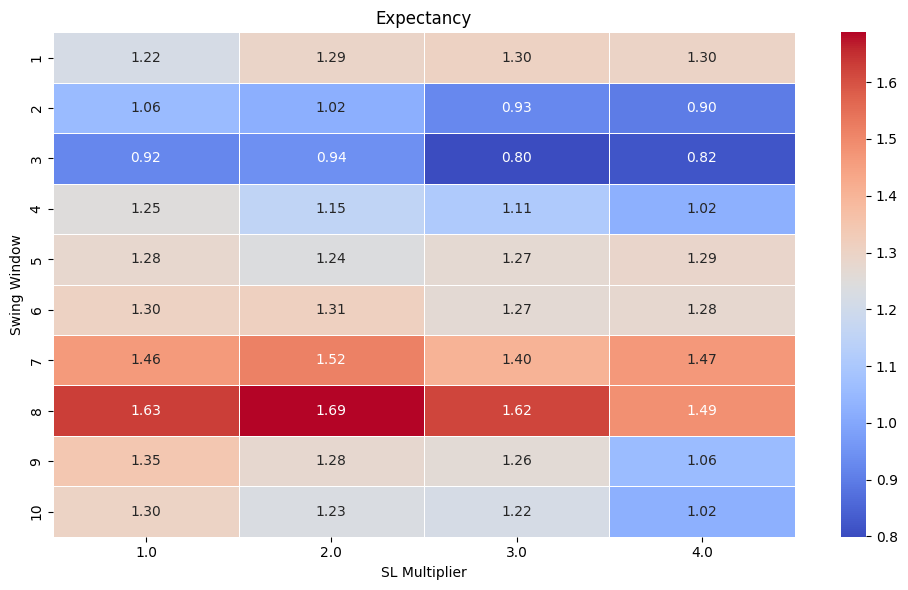

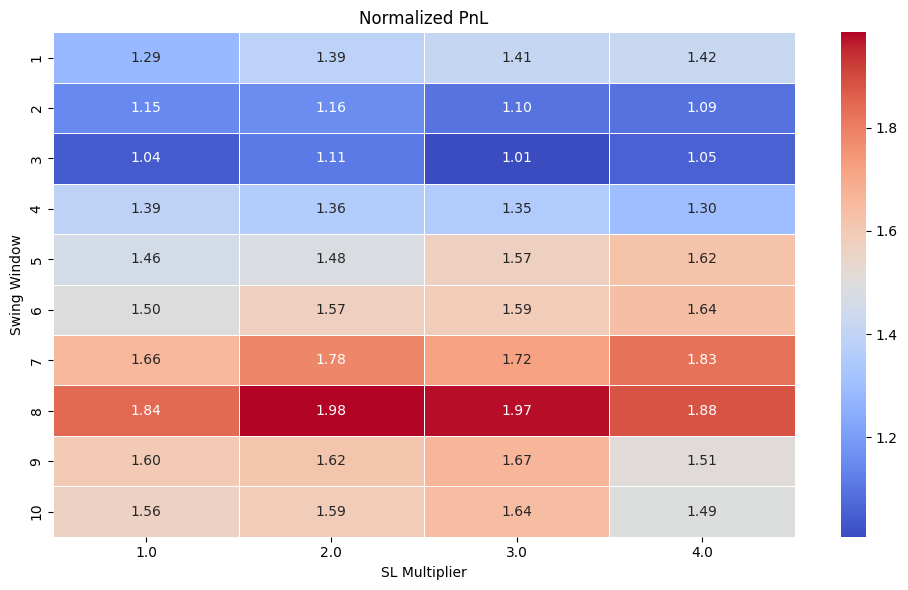

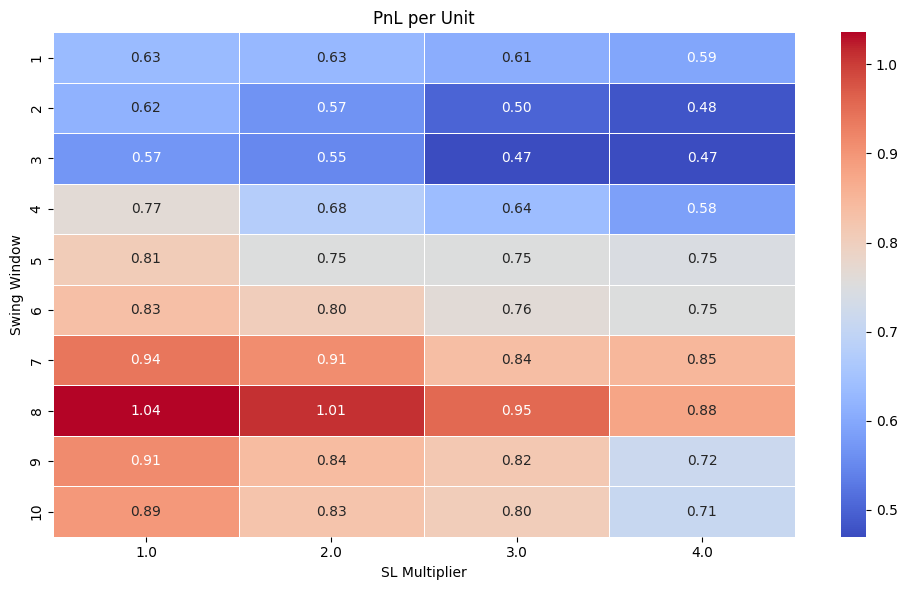

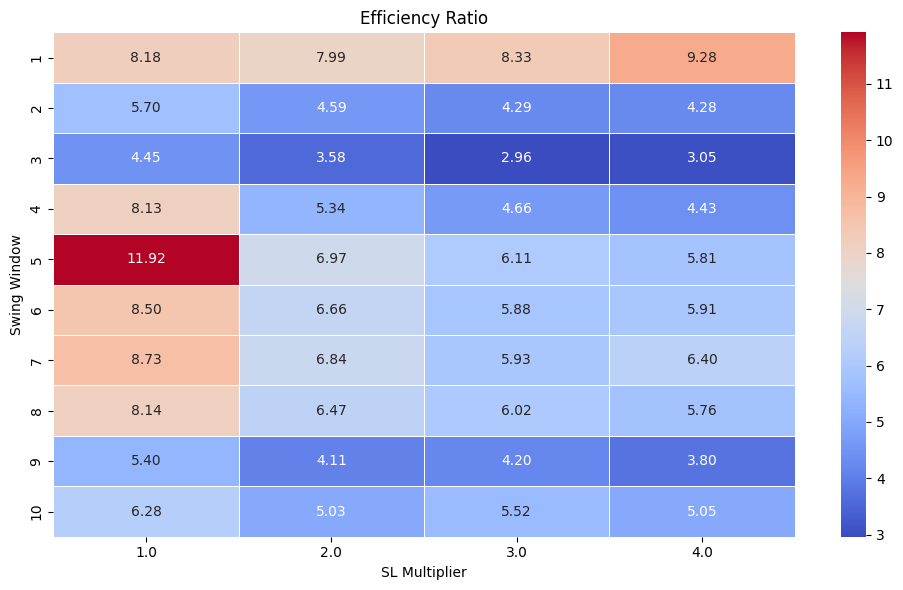

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
summary_path = r"Parameters Comparison Summary/all_trades_two_candle_entry_with_two_lots_on_one_candle.csv"
df = pd.read_csv(summary_path)

# Function to plot a heatmap for a given metric
def plot_heatmap(metric, title, cmap='coolwarm', fmt='.2f'):
    pivot = df.pivot(index="Window", columns="SL Multiplier", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5)
    plt.title(title)
    plt.xlabel("SL Multiplier")
    plt.ylabel("Swing Window")
    plt.tight_layout()
    plt.show()

# List of metrics and corresponding titles
metrics_to_plot = [
    ("Total Trades", "Total Trades"),
    ("Win Rate (%)", "Win Rate (%)"),
    ("Total PnL", "Total PnL"),
    ("Average PnL", "Average PnL"),
    ("Max Drawdown", "Max Drawdown"),
    ("Risk-Reward", "Risk-Reward Ratio"),
    ("Avg Win", "Average Win"),
    ("Avg Loss", "Average Loss"),
    ("Average MAE", "Average MAE"),
    ("Max MAE", "Max MAE"),
    ("Average MFE", "Average MFE"),
    ("Max MFE", "Max MFE"),
    ("Winning PnL", "Total Winning PnL"),
    ("Losing PnL", "Total Losing PnL"),
    ("Avg Trade Efficiency (%)", "Avg Trade Efficiency (%)"),
    ("Sharpe-like Ratio", "Sharpe-like Ratio"),
    ("Sortino Ratio", "Sortino Ratio"),
    ("Expectancy", "Expectancy"),
    ("Normalized PnL", "Normalized PnL"),
    ("PnL per Unit", "PnL per Unit"),
    ("Efficiency Ratio", "Efficiency Ratio"),
]

# Generate heatmaps
for metric, title in metrics_to_plot:
    plot_heatmap(metric, title)

